# CLIMADA Hazard Integration Workflow

**Purpose**: Convert gridded return periods (from Notebook 01) into CLIMADA Hazard flood depth maps using JRC flood data and CLIMADA-Petals.

**Prerequisites**:
- ✅ Completed Notebook 01 (especially Section 13.5: return period grids)
- ✅ Have `return-period.nc` files from Section 13.5
- ✅ CLIMADA and CLIMADA-petals installed

**What this notebook does**:
1. Loads gridded return periods from Notebook 01
2. Downloads JRC flood depth maps (8 return period layers)
3. Applies CLIMADA Petals regrid + flood_depth operations
4. Creates CLIMADA event-based Hazard objects (8 events, one per return period)
5. Saves hazard for use in impact calculations (Notebook 03)

**What this notebook does NOT do**:
- ❌ Re-run calibration (use Notebook 01)
- ❌ Re-calculate return periods (use Notebook 01)
- ❌ Calculate impacts (that's Notebook 03)

---

**Workflow**:
```
Notebook 01 (Calibration)        Notebook 02 (Hazard + Depth)    Notebook 03 (Impact)
├─ Generate return period grid    ├─ Load return period grid  →   ├─ Load hazard
├─ Save return-period.nc          ├─ Download JRC maps            ├─ Define exposure
└─ Done                           ├─ Petals regrid + flood_depth  ├─ Calculate impacts
                                  ├─ Create 8 event Hazard        └─ Trigger decisions
                                  └─ Save climada_hazard.hdf5
```

## Overview: From Return Periods to Flood Depth

**Input**: Gridded return period (lat/lon grid with values in **years**)
- Source: Notebook 01, Section 13.5
- Format: `return-period.nc` with dims (latitude, longitude)

**Process**: 
- Download JRC flood depth maps (8 return periods: 1, 10, 20, 50, 75, 100, 200, 500 years)
- Regrid return period grid to match JRC resolution (bilinear interpolation)
- Interpolate flood depth between JRC layers based on return period values
- Apply optional FLOPROS protection masking

**Output**: CLIMADA Hazard object
- 8 synthetic events (one per JRC return period)
- Intensity = flood depth (meters)
- Saved as HDF5 for Notebook 03

## 0) Environment prerequisites
Use **conda-forge** for CLIMADA + Petals.

```bash
mamba create -n climada_env -c conda-forge climada climada-petals
mamba activate climada_env
mamba install -c conda-forge xesmf rasterio geopandas pyyaml netcdf4 dask
```


In [1]:
import climada

In [2]:
# === Section 0: Environment Setup (PyArrow Workaround) ===

from __future__ import annotations

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import json
import logging
from pathlib import Path
from typing import Optional, Tuple
import sys
import subprocess
import os

print("="*70)
print("SECTION 0: Environment Setup - PyArrow Workaround")
print("="*70)

# 1. Check Python and environment info
env_name = os.path.basename(sys.prefix)
print(f"\n• Python environment info:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  Executable: {sys.executable}")
print(f"  Conda env: {sys.prefix}")

# 2. AGGRESSIVE PYARROW FIX: Monkeypatch BEFORE any other imports
print(f"\n• 🔧 CRITICAL FIX: PyArrow Windows DLL workaround...")
import sys

# Prevent dask from checking for pyarrow at import time
# This allows us to use CLIMADA without pyarrow being fully functional
sys.modules['pyarrow'] = None
sys.modules['pyarrow.lib'] = None

# Monkeypatch dask to skip pyarrow check
try:
    import dask
    # Disable dask's pyarrow requirement
    import dask._compatibility
    original_import = dask._compatibility.import_optional_dependency
    
    def patched_import(*args, **kwargs):
        if 'pyarrow' in str(args):
            return None  # Skip pyarrow import
        return original_import(*args, **kwargs)
    
    dask._compatibility.import_optional_dependency = patched_import
    print("  ✓ Dask patched to skip PyArrow check")
except Exception as e:
    print(f"  ⚠️  Dask patch attempt: {e}")

# 3. Import core libraries (no PyArrow needed)
print(f"\n• Importing core libraries...")
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import sparse

print(f"  ✓ Core libraries imported")

# 4. Try importing CLIMADA with patched environment
print(f"\n• Importing CLIMADA (with PyArrow workaround)...")
try:
    from climada.hazard import Hazard, Centroids
    print(f"  ✓ CLIMADA core imported")
    CLIMADA_AVAILABLE = True
except ImportError as e:
    print(f"  ⚠️  CLIMADA import failed: {str(e)[:100]}")
    print(f"     (PyArrow issue - will attempt alternative approach)")
    CLIMADA_AVAILABLE = False

# 5. Try importing CLIMADA-Petals if CLIMADA loaded
if CLIMADA_AVAILABLE:
    print(f"\n• Importing CLIMADA-Petals...")
    try:
        from climada_petals.hazard.rf_glofas.transform_ops import (
            regrid as petals_regrid,
            flood_depth as petals_flood_depth,
            apply_flopros as petals_apply_flopros,
        )
        from climada_petals.hazard.rf_glofas.setup import download_flopros_database
        print(f"  ✓ CLIMADA-Petals imported")
    except ImportError as e:
        print(f"  ⚠️  CLIMADA-Petals import failed: {e}")
        CLIMADA_AVAILABLE = False

# If CLIMADA still not available, provide diagnostic
if not CLIMADA_AVAILABLE:
    print(f"\n⚠️  CLIMADA/PyArrow still not available")
    print(f"\n🔧 MANUAL FIX REQUIRED (do this in terminal):")
    print(f"  1. Download Visual C++ redistributables:")
    print(f"     https://support.microsoft.com/en-us/help/2977003")
    print(f"  2. Or reinstall pyarrow:")
    print(f"     &\"C:\\Users\\duruenaramirez\\AppData\\Local\\miniforge3\\Scripts\\conda.exe\" install -n ibf-env -c conda-forge --force-reinstall -y pyarrow dask")
    print(f"  3. Then restart the Jupyter kernel")
    print(f"\n✓ Proceeding without CLIMADA (can use basic NumPy operations)")
else:
    print(f"\n✅ All CLIMADA imports successful")

# 6. Project imports
print(f"\n• Setting up project paths...")
REPO_ROOT = Path.cwd().parent.parent
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
print(f"  ✓ REPO_ROOT: {REPO_ROOT}")

# 7. Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("climada_hazard_notebook")

print(f"\n✅ SECTION 0 COMPLETE")
print(f"   CLIMADA available: {CLIMADA_AVAILABLE}")
if not CLIMADA_AVAILABLE:
    print(f"   ⚠️  Some features will be limited without CLIMADA")

SECTION 0: Environment Setup - PyArrow Workaround

• Python environment info:
  Python: 3.11.14
  Executable: c:\Users\duruenaramirez\AppData\Local\miniforge3\envs\PHL-Flood\python.exe
  Conda env: c:\Users\duruenaramirez\AppData\Local\miniforge3\envs\PHL-Flood

• 🔧 CRITICAL FIX: PyArrow Windows DLL workaround...
  ✓ Dask patched to skip PyArrow check

• Importing core libraries...
  ✓ Core libraries imported

• Importing CLIMADA (with PyArrow workaround)...
  ✓ CLIMADA core imported

• Importing CLIMADA-Petals...
  ✓ CLIMADA-Petals imported

✅ All CLIMADA imports successful

• Setting up project paths...
  ✓ REPO_ROOT: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL

✅ SECTION 0 COMPLETE
   CLIMADA available: True


In [ ]:
# === Section 0.5: Helper Functions (Mode Detection & Boundary Selection) ===

def detect_calibration_mode(processed_root, basin_id_hint=None, run_tag_hint=None):
    """
    Auto-detect calibration mode (basin vs municipality) by examining directory structure.
    Returns dict with mode, basin_id, run_tag, muni_gdf (if applicable), and aoi_boundary.
    
    Priority for mode detection:
    1. Read run_config.json (exported by notebook 01)
    2. Read ops/configs/basins/{basin_id}.yaml (user config)
    3. Default to "basin"
    
    Auto-selection priority (when no hints provided):
    - Finds the MOST RECENTLY CREATED run_config.json across all basins/runs
    - This ensures you always pick up the latest calibration run
    """
    import json
    import yaml
    
    calibration_root = processed_root / "calibration" / "evt_pot"
    
    if not calibration_root.exists():
        raise FileNotFoundError(f"Calibration root not found: {calibration_root}")
    
    # List available basin directories
    basin_dirs = [d for d in calibration_root.iterdir() if d.is_dir()]
    
    if not basin_dirs:
        raise RuntimeError(f"No basin directories found in {calibration_root}")
    
    # If BOTH hints provided, use them directly
    if basin_id_hint and run_tag_hint:
        basin_dir = calibration_root / basin_id_hint
        run_dir = basin_dir / run_tag_hint
        if not basin_dir.exists():
            raise ValueError(f"Basin directory not found: {basin_dir}")
        if not run_dir.exists():
            raise ValueError(f"Run directory not found: {run_dir}")
        print(f"  [AUTO] Using provided hints: {basin_id_hint}/{run_tag_hint}")
        basin_id = basin_id_hint
        run_tag = run_tag_hint
    
    # If only basin_id hint provided, find most recent run in that basin
    elif basin_id_hint and not run_tag_hint:
        basin_dir = calibration_root / basin_id_hint
        if not basin_dir.exists():
            raise ValueError(f"Basin directory not found: {basin_dir}")
        
        run_dirs = [d for d in basin_dir.iterdir() if d.is_dir()]
        if not run_dirs:
            raise RuntimeError(f"No run directories found in {basin_dir}")
        
        # Find most recent run_config.json in this basin
        run_configs = [(d, d / "run_config.json") for d in run_dirs if (d / "run_config.json").exists()]
        if run_configs:
            run_dir = max(run_configs, key=lambda x: x[1].stat().st_mtime)[0]
            print(f"  [AUTO] Basin hint: {basin_id_hint}, most recent run: {run_dir.name}")
        else:
            # Fallback to most recent directory if no JSON files
            run_dir = max(run_dirs, key=lambda d: d.stat().st_mtime)
            print(f"  [AUTO] Basin hint: {basin_id_hint}, most recent dir: {run_dir.name} (no JSON files found)")
        
        basin_id = basin_id_hint
        run_tag = run_dir.name
    
    # No hints - find the MOST RECENT run_config.json across ALL basins
    else:
        print(f"  [AUTO] Searching for most recent run_config.json across all basins...")
        
        all_run_configs = []
        for basin_d in basin_dirs:
            for run_d in basin_d.iterdir():
                if run_d.is_dir():
                    json_file = run_d / "run_config.json"
                    if json_file.exists():
                        all_run_configs.append((basin_d, run_d, json_file))
        
        if not all_run_configs:
            # Fallback: no JSON files found, use most recent run directory
            print(f"  [WARN] No run_config.json files found, falling back to most recent directory")
            basin_dir = max(basin_dirs, key=lambda d: d.stat().st_mtime)
            run_dirs = [d for d in basin_dir.iterdir() if d.is_dir()]
            run_dir = max(run_dirs, key=lambda d: d.stat().st_mtime) if run_dirs else None
            if not run_dir:
                raise RuntimeError(f"No run directories found in any basin")
        else:
            # Sort by JSON file modification time and pick most recent
            basin_dir, run_dir, json_file = max(all_run_configs, key=lambda x: x[2].stat().st_mtime)
            json_time = json_file.stat().st_mtime
            from datetime import datetime
            time_str = datetime.fromtimestamp(json_time).strftime("%Y-%m-%d %H:%M:%S")
            print(f"  [AUTO] Most recent: {basin_dir.name}/{run_dir.name} (created: {time_str})")
        
        basin_id = basin_dir.name
        run_tag = run_dir.name
    
    # === PRIORITY 1: Try to read run_config.json (exported by notebook 01) ===
    config_file = run_dir / "run_config.json"
    mode = None
    selected_municipalities = None
    
    if config_file.exists():
        try:
            metadata = json.loads(config_file.read_text())
            mode = metadata.get("selection_mode", "").lower()
            selected_municipalities = metadata.get("selected_municipalities")
            print(f"  [METADATA] Mode from run_config.json: {mode}")
        except Exception as e:
            print(f"  [WARN] Could not read metadata file: {e}")
    else:
        print(f"  [INFO] No metadata file found at: {config_file}")
    
    # === PRIORITY 2: Fall back to basin config YAML ===
    if mode not in ["municipality", "basin"]:
        config_path = REPO_ROOT / "ops" / "configs" / "basins" / f"{basin_id}.yaml"
        try:
            with open(config_path, 'r') as f:
                config = yaml.safe_load(f)
            mode = config.get("selection_mode", "basin").lower()
            print(f"  [YAML] Mode from basin config: {mode}")
        except Exception as e:
            print(f"  [WARN] Could not read basin config: {e}")
            mode = "basin"
    
    # === FALLBACK: Default to basin mode ===
    if mode not in ["municipality", "basin"]:
        mode = "basin"
        print(f"  [DEFAULT] Mode defaulting to: {mode}")
    
    # Load municipalities GeoDataFrame if in municipality mode
    muni_gdf = None
    aoi_boundary = None
    
    if mode == "municipality":
        # PRIORITY 1: Try direct AOI file from Notebook 01 output
        direct_aoi_file = run_dir / "aoi" / "municipality_aoi.geojson"
        if direct_aoi_file.exists():
            try:
                aoi_gdf = gpd.read_file(direct_aoi_file).to_crs("EPSG:4326")
                if not aoi_gdf.empty:
                    aoi_boundary = aoi_gdf.unary_union
                    print(f"  [OK] Loaded municipality AOI directly from: {direct_aoi_file.name}")
            except Exception as e:
                print(f"  [WARN] Could not load direct AOI file: {e}")
        
        # PRIORITY 2: Try admin shapefile with correct path
        if aoi_boundary is None:
            try:
                vectors_root = processed_root.parent / "raw" / "vectors" / "admin"
                ph_admin = vectors_root / "phl_cod_ab" / "phl_adm3.geojson"
                
                if ph_admin.exists():
                    admin_gdf = gpd.read_file(ph_admin).to_crs("EPSG:4326")
                    
                    # Try to load selected municipalities from metadata JSON first
                    if selected_municipalities:
                        muni_gdf = admin_gdf[admin_gdf.index.isin(selected_municipalities)].copy()
                        if not muni_gdf.empty:
                            aoi_boundary = muni_gdf.unary_union
                            print(f"  [OK] Loaded {len(muni_gdf)} municipalities from metadata")
                    
                    # Fallback: try text file or geojson file
                    if muni_gdf is None or muni_gdf.empty:
                        muni_names_file = basin_dir / "selected_municipalities.geojson"
                        if not muni_names_file.exists():
                            muni_names_file = basin_dir / "selected_municipalities.txt"
                        if muni_names_file.exists():
                            if muni_names_file.suffix == ".geojson":
                                selected_muni_gdf = gpd.read_file(muni_names_file).to_crs("EPSG:4326")
                                muni_gdf = selected_muni_gdf.copy()
                                aoi_boundary = muni_gdf.unary_union
                                print(f"  [OK] Loaded {len(muni_gdf)} municipalities from geojson file")
                            else:
                                selected_muni = [line.strip() for line in muni_names_file.read_text().splitlines() if line.strip()]
                                muni_gdf = admin_gdf[admin_gdf['NAME_3'].isin(selected_muni)].copy()
                                if not muni_gdf.empty:
                                    aoi_boundary = muni_gdf.unary_union
                                    print(f"  [OK] Loaded {len(muni_gdf)} municipalities from text file")
            except Exception as e:
                print(f"  [WARN] Could not load municipality data: {e}")
    
    # Fallback: use basin boundary if available
    if aoi_boundary is None:
        try:
            from philflood.geo.hydrobasins import read_vector, select_context_polygon
            vectors_root = processed_root.parent / "raw" / "vectors" / "hydrobasins"
            hb_path = vectors_root / "hydrobasins_philippines.shp"
            
            if hb_path.exists():
                hb_gdf = read_vector(hb_path, crs="EPSG:4326")
                # Use config to select basin - for now, take union of all valid geometries
                aoi_boundary = hb_gdf.unary_union
        except:
            pass
    
    # Ultimate fallback: use entire country bounds
    if aoi_boundary is None:
        if mode == "municipality":
            print(f"  [WARN] Municipality boundary not found, using Philippines country extent as fallback")
        aoi_boundary = box(116.0, 4.0, 127.0, 22.0)  # Philippines rough extent
    
    return {
        "mode": mode,
        "basin_id": basin_id,
        "run_tag": run_tag,
        "muni_gdf": muni_gdf,
        "aoi_boundary": aoi_boundary,
    }


def get_flood_zone_boundary(processed_root, mode, basin_id, muni_gdf=None):
    """
    Get the boundary polygon for JRC tile selection based on mode and basin_id.
    Returns a Shapely geometry (MultiPolygon or Polygon).
    """
    from shapely.geometry import box
    
    # If municipality mode with valid GeoDataFrame, use municipality union
    if mode == "municipality" and muni_gdf is not None and not muni_gdf.empty:
        return muni_gdf.unary_union
    
    # Otherwise, try to load basin boundary from config
    try:
        config_path = REPO_ROOT / "ops" / "configs" / "basins" / f"{basin_id}.yaml"
        import yaml
        
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        
        # If basin has explicit bbox in config, use it
        if "bbox" in config:
            bbox = config["bbox"]
            return box(bbox[0], bbox[1], bbox[2], bbox[3])  # [lon_min, lat_min, lon_max, lat_max]
    except:
        pass
    
    # Fallback: use Philippines extent
    return box(116.0, 4.0, 127.0, 22.0)


print(f"\n[OK] SECTION 0.5: Helper functions defined")
print(f"   - detect_calibration_mode() [auto-selects by run_config.json timestamp]")
print(f"   - get_flood_zone_boundary()")


[OK] SECTION 0.5: Helper functions defined
   - detect_calibration_mode() [auto-selects by run_config.json timestamp]
   - get_flood_zone_boundary()


In [4]:
# === Section 1: Unified Configuration (Mode-Aware & System-Optimized) ===

# ============================================================================
# PART 1A: USER CONFIGURATION (Edit these for different runs)
# ============================================================================

# 1.1: Auto-detection vs Manual Mode
AUTO_DETECT = True                    # Change to False for manual mode
basin_id_input = None                 # None = auto-detect by JSON timestamp OR specify e.g "Cagayan_01"
run_tag_input = None                  # None = auto-detect by JSON timestamp OR specify e.g "2026-01-19_calib-test"

# 1.2: Processing Algorithm Options
APPLY_FLOPROS = False                 # Apply FLOPROS flood protection masking
REGRID_METHOD = "bilinear"            # "bilinear" or "nearest" for petals_regrid
USE_RECLASSIFIED = False              # Use depth_reclass.tif vs depth.tif from JRC

# ============================================================================
# PART 1B: SYSTEM RESOURCE DETECTION (Auto-detect or override via environment)
# ============================================================================

def detect_system_resources():
    """Detect available RAM, storage type, and configure optimized parameters."""
    import os
    
    # Detect RAM
    try:
        import psutil
        mem = psutil.virtual_memory()
        available_gb = mem.available / (1024**3)
        total_gb = mem.total / (1024**3)
    except ImportError:
        try:
            import ctypes
            class MemInfo(ctypes.Structure):
                _fields_ = [("dwLength", ctypes.c_ulong),
                           ("dwMemoryLoad", ctypes.c_ulong),
                           ("ullTotalPhys", ctypes.c_ulonglong),
                           ("ullAvailPhys", ctypes.c_ulonglong),
                           ("ullTotalPageFile", ctypes.c_ulonglong),
                           ("ullAvailPageFile", ctypes.c_ulonglong),
                           ("ullTotalVirtual", ctypes.c_ulonglong),
                           ("ullAvailVirtual", ctypes.c_ulonglong),
                           ("ullAvailExtendedVirtual", ctypes.c_ulonglong)]
            
            mem_info = MemInfo()
            ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(mem_info))
            available_gb = mem_info.ullAvailPhys / (1024**3)
            total_gb = mem_info.ullTotalPhys / (1024**3)
        except Exception as e:
            # Ultimate fallback
            available_gb = 8.0
            total_gb = 16.0
    
    # Check for environment variable overrides
    env_low_ram = os.getenv("PHILFLOOD_LOW_RAM_MODE", "").lower() == "true"
    env_use_fast_io = os.getenv("USE_FAST_RASTERIO", "true").lower() == "true"
    
    # Storage type detection (simplified - assume SSD if total > 8GB, HDD otherwise)
    storage_type = "SSD" if total_gb >= 8 else "HDD"
    
    # Determine if low-RAM mode should be enabled
    low_ram_threshold = 8.0  # GB
    low_ram_mode = env_low_ram or (available_gb < low_ram_threshold)
    low_ram_reason = None
    
    if env_low_ram:
        low_ram_reason = "environment variable set"
    elif available_gb < low_ram_threshold:
        low_ram_reason = f"available RAM ({available_gb:.1f}GB) < {low_ram_threshold}GB threshold"
    
    # Set chunk sizes
    if low_ram_mode:
        chunks_xy = (256, 256)
        chunk_size_mb = 0.25
    else:
        chunks_xy = (512, 512)
        chunk_size_mb = 1.0
    
    return {
        'available_gb': available_gb,
        'total_gb': total_gb,
        'storage_type': storage_type,
        'low_ram_mode': low_ram_mode,
        'low_ram_reason': low_ram_reason,
        'chunks_xy': chunks_xy,
        'chunk_size_mb': chunk_size_mb,
        'use_fast_rasterio': env_use_fast_io,
        'netcdf_engine': 'scipy',
    }

# Run resource detection
sys_resources = detect_system_resources()

# ============================================================================
# PART 1C: PATHS & DIRECTORIES (depend on AUTO_DETECT mode)
# ============================================================================

# 1.3: Set root paths
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"

# 1.4: Detect mode and configure paths
if AUTO_DETECT:
    mode_info = detect_calibration_mode(PROCESSED_ROOT, basin_id_input, run_tag_input)
    mode = mode_info["mode"]
    BASIN_ID = mode_info["basin_id"]
    RUN_TAG = mode_info["run_tag"]
    MUNI_GDF = mode_info["muni_gdf"]
    AOI_BOUNDARY = mode_info["aoi_boundary"]
else:
    # Manual mode: user must specify both
    if not basin_id_input or not run_tag_input:
        raise ValueError("Manual mode requires both basin_id_input and run_tag_input to be specified")
    
    BASIN_ID = basin_id_input
    RUN_TAG = run_tag_input
    mode = "basin"  # Default to basin mode in manual configuration
    MUNI_GDF = None
    AOI_BOUNDARY = None

# 1.5: Construct calibration paths
calibration_root = PROCESSED_ROOT / "calibration" / "evt_pot" / BASIN_ID / RUN_TAG
CALIBRATION_OUTPUT = calibration_root
RETURN_PERIOD_NC = calibration_root / "return-period_all.nc"

# 1.6: Construct hazard output paths
HAZARD_OUTPUT = calibration_root
VIZ_OUTPUT = calibration_root / "figures"

# Ensure output directories exist
HAZARD_OUTPUT.mkdir(parents=True, exist_ok=True)
VIZ_OUTPUT.mkdir(parents=True, exist_ok=True)

# 1.7: JRC flood map configuration
JRC_BASE_URL = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard/"
JRC_CACHE = REPO_ROOT / "data" / "raw" / "jrc_flood_maps"
JRC_RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]

# ============================================================================
# PART 1D: SYSTEM OPTIMIZATION SETTINGS
# ============================================================================

# Extract system resource settings
LOW_RAM_MODE = sys_resources['low_ram_mode']
DEFAULT_CHUNKS_XY = sys_resources['chunks_xy']
USE_FAST_RASTERIO = sys_resources['use_fast_rasterio']
NETCDF_ENGINE = sys_resources['netcdf_engine']

# ============================================================================
# PART 1E: PROCESSING CONFIGURATION SUMMARY
# ============================================================================

# Build configuration summary for logging
PROCESSING_CONFIG = {
    "mode": mode,
    "basin_id": BASIN_ID,
    "run_tag": RUN_TAG,
    "apply_flopros": APPLY_FLOPROS,
    "regrid_method": REGRID_METHOD,
    "use_reclassified": USE_RECLASSIFIED,
    "low_ram_mode": LOW_RAM_MODE,
    "chunks_xy": DEFAULT_CHUNKS_XY,
    "netcdf_engine": NETCDF_ENGINE,
    "use_fast_rasterio": USE_FAST_RASTERIO,
}

# Display configuration summary
print("=" * 70)
print("✅ SECTION 1: UNIFIED CONFIGURATION COMPLETE")
print("=" * 70)
print(f"\n🔧 MODE CONFIGURATION:")
print(f"  Mode: {mode.upper()}")
print(f"  Basin/Municipality ID: {BASIN_ID}")
print(f"  Run tag: {RUN_TAG}")
if MUNI_GDF is not None and not MUNI_GDF.empty:
    print(f"  Municipalities: {len(MUNI_GDF)} loaded")

print(f"\n📂 PATHS:")
print(f"  Input (Return Period NC): {RETURN_PERIOD_NC.name}")
print(f"  Output (Hazard): {RUN_TAG}")

print(f"\n⚙️  ALGORITHM OPTIONS:")
print(f"  Apply FLOPROS: {APPLY_FLOPROS}")
print(f"  Regrid method: {REGRID_METHOD}")
print(f"  Use reclassified depth: {USE_RECLASSIFIED}")

print(f"\n💾 SYSTEM RESOURCES:")
print(f"  Available RAM: {sys_resources['available_gb']:.1f}GB / {sys_resources['total_gb']:.1f}GB")
if LOW_RAM_MODE:
    print(f"  Low-RAM mode: True ({sys_resources['low_ram_reason']})")
else:
    print(f"  Low-RAM mode: False")
print(f"  Chunk size: {DEFAULT_CHUNKS_XY[0]}×{DEFAULT_CHUNKS_XY[1]} pixels (~{sys_resources['chunk_size_mb']:.2f}MB per chunk)")
print(f"  Fast rasterio: {USE_FAST_RASTERIO}")
print(f"  NetCDF engine: {NETCDF_ENGINE}")

print(f"\n📋 CONFIG VALIDATION:")
print(f"  ✓ User settings defined (AUTO_DETECT={AUTO_DETECT})")
print(f"  ✓ System resources detected")
print(f"  ✓ Paths constructed (JRC_RETURN_PERIODS={JRC_RETURN_PERIODS})")
print(f"  ✓ All variables available for downstream sections")

print(f"\n  Use these variables in all subsequent cells:")
print(f"    - mode, BASIN_ID, RUN_TAG (mode-aware processing)")
print(f"    - APPLY_FLOPROS, REGRID_METHOD, USE_RECLASSIFIED (algorithm control)")
print(f"    - LOW_RAM_MODE, DEFAULT_CHUNKS_XY, NETCDF_ENGINE (resource management)")
print()

  [AUTO] Searching for most recent run_config.json across all basins...
  [AUTO] Most recent: MUNI_SELECTION/2026-01-19_calib-test (created: 2026-02-09 18:38:06)
  [METADATA] Mode from run_config.json: municipality
✅ SECTION 1: UNIFIED CONFIGURATION COMPLETE

🔧 MODE CONFIGURATION:
  Mode: MUNICIPALITY
  Basin/Municipality ID: MUNI_SELECTION
  Run tag: 2026-01-19_calib-test

📂 PATHS:
  Input (Return Period NC): return-period_all.nc
  Output (Hazard): 2026-01-19_calib-test

⚙️  ALGORITHM OPTIONS:
  Apply FLOPROS: False
  Regrid method: bilinear
  Use reclassified depth: False

💾 SYSTEM RESOURCES:
  Available RAM: 3.0GB / 15.6GB
  Low-RAM mode: True (available RAM (3.0GB) < 8.0GB threshold)
  Chunk size: 256×256 pixels (~0.25MB per chunk)
  Fast rasterio: True
  NetCDF engine: scipy

📋 CONFIG VALIDATION:
  ✓ User settings defined (AUTO_DETECT=True)
  ✓ System resources detected
  ✓ Paths constructed (JRC_RETURN_PERIODS=[10, 20, 50, 75, 100, 200, 500])
  ✓ All variables available for downs

In [5]:
# === Section 2: Load Return Period Grid ===

print("\n" + "="*70)
print("SECTION 2: Load Return Period Grid from Notebook 01")
print("="*70)

# Validate input exists
if not RETURN_PERIOD_NC.exists():
    print(f"\n❌ Return period file not found: {RETURN_PERIOD_NC}")
    print(f"\n➡️  Please:")
    print(f"  1. Run Notebook 01 to generate calibration outputs")
    print(f"  2. Run Section 13.5 to generate return period grids")
    print(f"  3. Verify run_tag matches: {RUN_TAG}")
    raise FileNotFoundError(RETURN_PERIOD_NC)

# Load dataset containing all return period layers with LAZY LOADING
print(f"\n• Loading: {RETURN_PERIOD_NC.name} (with lazy loading for memory efficiency)")
ds_rp = xr.open_dataset(RETURN_PERIOD_NC, chunks='auto')  # Lazy load with automatic chunking

print(f"\n📊 Return period dataset structure:")
print(f"  Dimensions: {dict(ds_rp.dims)}")
print(f"  Variables: {list(ds_rp.data_vars.keys())}")
print(f"  Coordinates: {list(ds_rp.coords.keys())}")

# Extract lats/lons for basin polygon
lats_all = ds_rp.latitude.values
lons_all = ds_rp.longitude.values

print(f"\n📍 Grid extent:")
print(f"  Latitude: [{lats_all.min():.4f}, {lats_all.max():.4f}]")
print(f"  Longitude: [{lons_all.min():.4f}, {lons_all.max():.4f}]")
print(f"  Grid cells: {len(lats_all)} × {len(lons_all)} = {len(lats_all) * len(lons_all):,}")

# For now, use the median return period as representative
# (We'll extract specific RPs for each event layer when needed)
rp_vars = [v for v in ds_rp.data_vars if 'return_period' in v.lower()]
print(f"\n📊 Available return period variables: {rp_vars}")


SECTION 2: Load Return Period Grid from Notebook 01

• Loading: return-period_all.nc (with lazy loading for memory efficiency)

📊 Return period dataset structure:
  Dimensions: {'latitude': 14, 'longitude': 21}
  Variables: ['return_period_RP10', 'return_period_RP20', 'return_period_RP50', 'return_period_RP75', 'return_period_RP100', 'return_period_RP200', 'return_period_RP500']
  Coordinates: ['latitude', 'longitude']

📍 Grid extent:
  Latitude: [17.7750, 18.4250]
  Longitude: [121.4250, 122.4250]
  Grid cells: 14 × 21 = 294

📊 Available return period variables: ['return_period_RP10', 'return_period_RP20', 'return_period_RP50', 'return_period_RP75', 'return_period_RP100', 'return_period_RP200', 'return_period_RP500']


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_17808\3405899559.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds_rp.dims)}")


In [6]:
# === Section 3: Download JRC Tile Index ===

print("\n" + "="*70)
print("SECTION 3: Download JRC Tile Index and Flood Maps")
print("="*70)

import requests
import re
from pathlib import Path

# --- IMPORTANT: JRC only provides these 7 RPs (no RP1 folder) ---
JRC_RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]  # per JRC directory structure

tile_index_path = JRC_CACHE / "tile_extents.geojson"
JRC_CACHE.mkdir(parents=True, exist_ok=True)

# Download tile index if needed
if not tile_index_path.exists():
    print(f"\n• Downloading JRC tile index...")
    url = JRC_BASE_URL + "tile_extents.geojson"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    tile_index_path.write_bytes(response.content)
    print(f"  ✓ Saved: {tile_index_path.name}")

# Load tile index
print(f"\n• Loading tile index...")
tiles_gdf = gpd.read_file(tile_index_path).to_crs("EPSG:4326")
print(f"  Total tiles in index: {len(tiles_gdf)}")

# Select tiles using mode-aware boundary (from SECTION 1)
print(f"\n• Selecting tiles for {mode.upper()} mode:")
tiles_sel = tiles_gdf[tiles_gdf.intersects(AOI_BOUNDARY)].copy()

# --- After tiles_sel is created ---

# JRC tile index uses:
#   id   -> numeric tile id used in filenames (e.g. 231)
#   name -> tile label like N20_E120
required_cols = {"id", "name"}
if not required_cols.issubset(set(tiles_sel.columns)):
    print("❌ tile_extents.geojson missing expected columns.")
    print("Available columns:", list(tiles_sel.columns))
    raise ValueError("tile_extents.geojson missing id/name columns.")

tiles_sel = tiles_sel.copy()
tiles_sel["tile_code"] = "ID" + tiles_sel["id"].astype(str) + "_" + tiles_sel["name"].astype(str)

tile_codes = sorted(tiles_sel["tile_code"].dropna().unique().tolist())

print(f"\n📍 Tiles intersecting basin extent:")
print(f"  Selected tiles: {len(tile_codes)}")
print(f"  Example tile_code: {tile_codes[0]}")
print(f"  Tile codes: {tile_codes[:3]}... ({len(tile_codes)} total)")


def download_jrc_tile(rp, tile_code, output_dir):
    """Download a single JRC flood map tile (depth or depth_reclass)."""
    suffix = "_depth_reclass.tif" if USE_RECLASSIFIED else "_depth.tif"
    fname = f"{tile_code}_RP{rp}{suffix}"
    url = f"{JRC_BASE_URL}RP{rp}/{fname}"
    out_path = output_dir / fname

    if out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    try:
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
        return out_path
    except Exception as e:
        print(f"    ⚠️  Failed: {url} :: {e}")
        return None


# Download tiles for each return period
print(f"\n• Downloading JRC flood maps...")
manifest = []

for rp in JRC_RETURN_PERIODS:
    rp_dir = JRC_CACHE / f"RP{rp}"
    rp_dir.mkdir(exist_ok=True)

    success_count = 0
    for tile_code in tile_codes:
        out_path = download_jrc_tile(rp, tile_code, rp_dir)
        if out_path:
            manifest.append({"rp": int(rp), "tile_code": tile_code, "path": str(out_path)})
            success_count += 1

    print(f"  RP={rp:3d}yr: {success_count:2d}/{len(tile_codes)} tiles")

if not manifest:
    raise RuntimeError("❌ No tiles downloaded successfully.")


SECTION 3: Download JRC Tile Index and Flood Maps

• Loading tile index...
  Total tiles in index: 271

• Selecting tiles for MUNICIPALITY mode:

📍 Tiles intersecting basin extent:
  Selected tiles: 6
  Example tile_code: ID218_N30_E110
  Tile codes: ['ID218_N30_E110', 'ID219_N20_E110', 'ID220_N10_E110']... (6 total)

• Downloading JRC flood maps...
  RP= 10yr:  6/6 tiles
  RP= 20yr:  6/6 tiles
  RP= 50yr:  6/6 tiles
  RP= 75yr:  6/6 tiles
  RP=100yr:  6/6 tiles
  RP=200yr:  6/6 tiles
  RP=500yr:  6/6 tiles


In [7]:
# === Section 3.5: Configuration Validation & Status Check ===
# NOTE: System resources were already detected in SECTION 1
# This cell validates that all configuration is in place and ready for processing

print("\n" + "="*70)
print("SECTION 3.5: Configuration Validation & Status Check")
print("="*70)

print(f"\n✅ Configuration Status:")

# Validate all critical config variables are defined
required_vars = {
    'mode': str,
    'BASIN_ID': str,
    'RUN_TAG': str,
    'APPLY_FLOPROS': bool,
    'REGRID_METHOD': str,
    'USE_RECLASSIFIED': bool,
    'LOW_RAM_MODE': bool,
    'DEFAULT_CHUNKS_XY': tuple,
    'USE_FAST_RASTERIO': bool,
    'NETCDF_ENGINE': str,
    'RETURN_PERIOD_NC': 'Path',
    'HAZARD_OUTPUT': 'Path',
}

missing = []
for var_name in required_vars.keys():
    if var_name not in globals():
        missing.append(var_name)
    else:
        print(f"  ✓ {var_name} is defined")

if missing:
    print(f"\n❌ Missing configuration variables: {missing}")
    print(f"   Please ensure SECTION 1 executed successfully")
    raise RuntimeError(f"Configuration incomplete: missing {missing}")

print(f"\n📋 Configuration Summary (from SECTION 1):")
print(f"  Mode: {mode.upper()}")
print(f"  Basin ID: {BASIN_ID}")
print(f"  Run tag: {RUN_TAG}")
print(f"  Algorithm - APPLY_FLOPROS: {APPLY_FLOPROS}")
print(f"  Algorithm - REGRID_METHOD: {REGRID_METHOD}")
print(f"  Algorithm - USE_RECLASSIFIED: {USE_RECLASSIFIED}")
print(f"  System - LOW_RAM_MODE: {LOW_RAM_MODE}")
print(f"  System - CHUNKS: {DEFAULT_CHUNKS_XY}")
print(f"  System - FAST_RASTERIO: {USE_FAST_RASTERIO}")
print(f"  System - NETCDF_ENGINE: {NETCDF_ENGINE}")

print(f"\n🔄 Configuration Dependencies:")
print(f"  When APPLY_FLOPROS=True:")
print(f"    → FLOPROS protection masks will be applied to return period grids")
print(f"  When REGRID_METHOD='{REGRID_METHOD}':")
print(f"    → Return periods will be regridded using {REGRID_METHOD} interpolation")
print(f"  When USE_RECLASSIFIED=={USE_RECLASSIFIED}:")
depth_suffix = "depth_reclass.tif (reclassified)" if USE_RECLASSIFIED else "depth.tif (original)"
print(f"    → JRC flood maps will use {depth_suffix}")
print(f"  When LOW_RAM_MODE=={LOW_RAM_MODE}:")
print(f"    → Processing will use {DEFAULT_CHUNKS_XY[0]}×{DEFAULT_CHUNKS_XY[1]} pixel chunks")

print(f"\n✅ SECTION 3.5 COMPLETE - Configuration validated and ready")
print(f"   Proceed with SECTION 4 (JRC Tile Merging)")



SECTION 3.5: Configuration Validation & Status Check

✅ Configuration Status:
  ✓ mode is defined
  ✓ BASIN_ID is defined
  ✓ RUN_TAG is defined
  ✓ APPLY_FLOPROS is defined
  ✓ REGRID_METHOD is defined
  ✓ USE_RECLASSIFIED is defined
  ✓ LOW_RAM_MODE is defined
  ✓ DEFAULT_CHUNKS_XY is defined
  ✓ USE_FAST_RASTERIO is defined
  ✓ NETCDF_ENGINE is defined
  ✓ RETURN_PERIOD_NC is defined
  ✓ HAZARD_OUTPUT is defined

📋 Configuration Summary (from SECTION 1):
  Mode: MUNICIPALITY
  Basin ID: MUNI_SELECTION
  Run tag: 2026-01-19_calib-test
  Algorithm - APPLY_FLOPROS: False
  Algorithm - REGRID_METHOD: bilinear
  Algorithm - USE_RECLASSIFIED: False
  System - LOW_RAM_MODE: True
  System - CHUNKS: (256, 256)
  System - FAST_RASTERIO: True
  System - NETCDF_ENGINE: scipy

🔄 Configuration Dependencies:
  When APPLY_FLOPROS=True:
    → FLOPROS protection masks will be applied to return period grids
  When REGRID_METHOD='bilinear':
    → Return periods will be regridded using bilinear interpo

In [8]:
# === SECTION 3.75: Configuration Usage Map & Troubleshooting Guide ===
# This cell documents which configuration parameters are used in each section

print("\n" + "="*70)
print("CONFIGURATION USAGE MAP - Which config is used where")
print("="*70)

config_usage = {
    "SECTION 1": {
        "Purpose": "Consolidate all configuration (mode detection + system resources)",
        "Config Parameters": ["AUTO_DETECT", "basin_id_input", "run_tag_input", "APPLY_FLOPROS", "REGRID_METHOD", "USE_RECLASSIFIED"],
        "Outputs": ["mode", "BASIN_ID", "RUN_TAG", "MUNI_GDF", "AOI_BOUNDARY", "LOW_RAM_MODE", "DEFAULT_CHUNKS_XY", "NETCDF_ENGINE"],
    },
    "SECTION 2": {
        "Purpose": "Load Return Period Grid from Notebook 01",
        "Config Used": ["RETURN_PERIOD_NC", "DEFAULT_CHUNKS_XY"],
        "Affected By": ["LOW_RAM_MODE"],
    },
    "SECTION 3": {
        "Purpose": "Download JRC Tile Index and Flood Maps",
        "Config Used": ["mode", "MUNI_GDF", "AOI_BOUNDARY", "USE_RECLASSIFIED"],
        "Affected By": ["Mode selection (auto/manual)"],
    },
    "SECTION 3.5": {
        "Purpose": "Validate configuration and check dependencies",
        "Config Used": ["All configuration variables"],
        "Affected By": ["SECTION 1 outputs"],
    },
    "SECTION 4": {
        "Purpose": "Merge JRC Flood Maps Tiles",
        "Config Used": ["DEFAULT_CHUNKS_XY", "NETCDF_ENGINE"],
        "Affected By": ["LOW_RAM_MODE"],
    },
    "SECTION 5": {
        "Purpose": "Regrid & Interpolate Flood Depth",
        "Config Used": ["REGRID_METHOD", "APPLY_FLOPROS", "DEFAULT_CHUNKS_XY"],
        "Affected By": ["LOW_RAM_MODE", "Algorithm options"],
        "Critical Parameters": {
            "REGRID_METHOD": "bilinear (default) or nearest - changes interpolation method",
            "APPLY_FLOPROS": "True enables protection masking, False skips it",
        },
    },
    "SECTION 6": {
        "Purpose": "Create CLIMADA Hazard Object",
        "Config Used": ["HAZARD_OUTPUT", "BASIN_ID"],
        "Mode-Agnostic": True,
    },
    "SECTION 7": {
        "Purpose": "Workflow Complete - Summary and Next Steps",
        "Config Used": ["HAZARD_OUTPUT"],
        "Mode-Agnostic": True,
    },
}

for section, details in config_usage.items():
    print(f"\n{section}:")
    print(f"  Purpose: {details.get('Purpose', 'N/A')}")
    if "Config Parameters" in details:
        print(f"  Config Parameters Set: {', '.join(details['Config Parameters'])}")
    if "Outputs" in details:
        print(f"  Outputs: {', '.join(details['Outputs'])}")
    if "Config Used" in details:
        print(f"  Config Used: {', '.join(details['Config Used'])}")
    if "Affected By" in details:
        affected = details['Affected By']
        if isinstance(affected, list):
            print(f"  Affected By: {', '.join(affected)}")
        else:
            print(f"  Affected By: {affected}")
    if "Mode-Agnostic" in details and details["Mode-Agnostic"]:
        print(f"  ✓ Mode-Agnostic (works regardless of auto-detect or manual mode)")
    if "Critical Parameters" in details:
        print(f"  Critical Parameters:")
        for param, desc in details["Critical Parameters"].items():
            print(f"    - {param}: {desc}")

print("\n" + "="*70)
print("Mode-Aware Behavior Summary")
print("="*70)
print(f"\nCurrent Mode: {mode.upper()}")
print(f"  Basin/Municipality ID: {BASIN_ID}")
print(f"  Run Tag: {RUN_TAG}")
if mode == "municipality" and MUNI_GDF is not None:
    print(f"  Selected Municipalities: {len(MUNI_GDF)}")
    print(f"  AOI Boundary Type: MultiPolygon (union of municipality boundaries)")
else:
    print(f"  AOI Boundary Type: Basin boundary or Philippines extent (fallback)")

print(f"\nMode Implications:")
print(f"  • SECTION 3 (JRC tile selection): Uses {'MUNI_GDF' if mode == 'municipality' else 'basin boundary'}")
print(f"  • SECTIONS 4-7: Process identical return-period grids (mode-agnostic)")
print(f"  • Output paths: {HAZARD_OUTPUT}")

print(f"\n✅ SECTION 3.75 COMPLETE - Configuration map available for reference")
print(f"   If any section fails, check 'Config Used' for this section above")



CONFIGURATION USAGE MAP - Which config is used where

SECTION 1:
  Purpose: Consolidate all configuration (mode detection + system resources)
  Config Parameters Set: AUTO_DETECT, basin_id_input, run_tag_input, APPLY_FLOPROS, REGRID_METHOD, USE_RECLASSIFIED
  Outputs: mode, BASIN_ID, RUN_TAG, MUNI_GDF, AOI_BOUNDARY, LOW_RAM_MODE, DEFAULT_CHUNKS_XY, NETCDF_ENGINE

SECTION 2:
  Purpose: Load Return Period Grid from Notebook 01
  Config Used: RETURN_PERIOD_NC, DEFAULT_CHUNKS_XY
  Affected By: LOW_RAM_MODE

SECTION 3:
  Purpose: Download JRC Tile Index and Flood Maps
  Config Used: mode, MUNI_GDF, AOI_BOUNDARY, USE_RECLASSIFIED
  Affected By: Mode selection (auto/manual)

SECTION 3.5:
  Purpose: Validate configuration and check dependencies
  Config Used: All configuration variables
  Affected By: SECTION 1 outputs

SECTION 4:
  Purpose: Merge JRC Flood Maps Tiles
  Config Used: DEFAULT_CHUNKS_XY, NETCDF_ENGINE
  Affected By: LOW_RAM_MODE

SECTION 5:
  Purpose: Regrid & Interpolate Flood 

In [9]:
# === Section 4: Merge JRC Flood Maps Tiles ===

print("\n" + "="*70)
print("SECTION 4: Merge JRC Flood Maps Tiles")
print("="*70)

import rasterio
from rasterio.merge import merge as rio_merge

flood_maps_path = HAZARD_OUTPUT / "flood-maps_intermediate.nc"

if flood_maps_path.exists():
    print(f"\n• Using existing flood maps: {flood_maps_path.name}")
    flood_maps = xr.open_dataarray(flood_maps_path)
    print(f"  ✓ flood_maps loaded: {flood_maps.shape}")
    print(f"  Return periods: {list(flood_maps.return_period.values)}")
else:
    # Determine tile filename suffix
    suffix = "_depth_reclass.tif" if USE_RECLASSIFIED else "_depth.tif"

    flood_maps_list = []
    rp_available = []

    for rp in JRC_RETURN_PERIODS:
        rp_dir = JRC_CACHE / f"RP{rp}"
        if not rp_dir.exists():
            print(f"  ⚠️  RP{rp} directory missing: {rp_dir}")
            continue

        # Build expected tile paths from Section 3 selection
        tile_paths = [rp_dir / f"{tile_code}_RP{rp}{suffix}" for tile_code in tile_codes]
        tile_paths = [p for p in tile_paths if p.exists()]

        if not tile_paths:
            print(f"  ⚠️  No tiles found for RP{rp} (suffix: {suffix})")
            continue

        print(f"\n• RP{rp}: merging {len(tile_paths)} tiles...")

        srcs = [rasterio.open(p) for p in tile_paths]
        mosaic, out_trans = rio_merge(srcs)
        for src in srcs:
            src.close()

        # rasterio returns (bands, height, width); JRC tiles are single-band
        arr = mosaic[0].astype("float64")
        height, width = arr.shape

        # Build lon/lat coordinates (cell-centered)
        lons = out_trans.c + out_trans.a * (np.arange(width) + 0.5)
        lats = out_trans.f + out_trans.e * (np.arange(height) + 0.5)

        # Ensure latitude is ascending for downstream xarray operations
        if lats[0] > lats[-1]:
            lats = lats[::-1]
            arr = arr[::-1, :]

        da = xr.DataArray(
            arr,
            coords={"latitude": lats, "longitude": lons},
            dims=("latitude", "longitude"),
            name="flood_maps",
        )

        flood_maps_list.append(da)
        rp_available.append(int(rp))

    if not flood_maps_list:
        raise RuntimeError("❌ No flood map mosaics created. Check Section 3 downloads.")

    # Stack into a single DataArray with return_period dimension
    flood_maps = xr.concat(flood_maps_list, dim="return_period")
    flood_maps = flood_maps.assign_coords(return_period=np.array(rp_available, dtype=np.int64))
    flood_maps = flood_maps.sortby("return_period")

    # Save intermediate product for reuse
    flood_maps.to_netcdf(flood_maps_path)

    print(f"\n✓ flood_maps created: {flood_maps.shape}")
    print(f"  Return periods: {list(flood_maps.return_period.values)}")
    print(f"  Saved: {flood_maps_path}")



SECTION 4: Merge JRC Flood Maps Tiles

• RP10: merging 6 tiles...

• RP20: merging 6 tiles...

• RP50: merging 6 tiles...

• RP75: merging 6 tiles...

• RP100: merging 6 tiles...

• RP200: merging 6 tiles...


2026-02-09 19:26:22,948 | WARNING | CPLE_OutOfMemory:GDALNoDataMaskBand::IRasterIO(): cannot allocate 11999 x 11999 x 4 bytes. Falling back to block-based approach


MemoryError: Unable to allocate 137. MiB for an array with shape (1, 11999, 11999) and data type bool

In [ ]:
# === Section 5: Apply CLIMADA Petals Regrid + Flood Depth to All Return Periods ===
# ⚙️  CONFIG PARAMETERS USED IN THIS SECTION:
#   • REGRID_METHOD (default: "bilinear") → controls interpolation method for petals_regrid()
#   • APPLY_FLOPROS (default: False) → conditionally applies FLOPROS protection masking
#   • LOW_RAM_MODE → controls memory-efficient processing when True
#   • DEFAULT_CHUNKS_XY → controls chunk size for dask operations
# 
# MODE-DEPENDENT BEHAVIOR:
#   • For "municipality" mode: AOI_BOUNDARY used to select JRC tiles (earlier sections)
#   • For "basin" mode: Use full basin boundary (earlier sections)
#   This section is MODE-AGNOSTIC (processes any valid return-period grid)
# ============================================================================

from climada_petals.hazard.rf_glofas.transform_ops import sel_lon_lat_slice
import re

print("\n" + "="*70)
print("SECTION 5: Regrid & Interpolate Flood Depth for All Return Periods")
print("="*70)
print(f"\n📋 Configuration in use:")
print(f"  REGRID_METHOD: {REGRID_METHOD}")
print(f"  APPLY_FLOPROS: {APPLY_FLOPROS}")
print(f"  LOW_RAM_MODE: {LOW_RAM_MODE}")
print(f"  DEFAULT_CHUNKS_XY: {DEFAULT_CHUNKS_XY}")

rp_regrid_path = HAZARD_OUTPUT / "return-period_regrid_all.nc"
depth_path = HAZARD_OUTPUT / "flood-depth_all.nc"
use_precomputed = rp_regrid_path.exists() and depth_path.exists()

if use_precomputed:
    print("\n• Using precomputed outputs from disk...")
    rp_regrid = xr.open_dataarray(rp_regrid_path)
    flood_depth = xr.open_dataarray(depth_path)
    print(f"  ✓ {rp_regrid_path.name} loaded")
    print(f"  ✓ {depth_path.name} loaded")
    print(f"  Events: {len(flood_depth.event.values)}")
    print(f"\n✓ Section 5 complete - reused precomputed outputs")
else:
    # === SAFETY CHECK: Ensure flood_maps exists (from Section 4) ===
    if 'flood_maps' not in globals():
        flood_maps_path = HAZARD_OUTPUT / "flood-maps_intermediate.nc"
        if flood_maps_path.exists():
            # Use default chunks if not defined
            if 'DEFAULT_CHUNKS_XY' not in globals():
                DEFAULT_CHUNKS_XY = (256, 256)
            print("\n⚠️  flood_maps not found in memory. Reloading from disk...")
            flood_maps = xr.open_dataarray(
                flood_maps_path,
                chunks={"return_period": -1, "latitude": DEFAULT_CHUNKS_XY[0], "longitude": DEFAULT_CHUNKS_XY[1]},
            ).astype("float64")
            print("  ✓ flood_maps reloaded from disk")
        else:
            raise NameError("flood_maps not found. Please run Section 4 first to generate flood-maps_intermediate.nc")

    # === CRITICAL FIX: Use NUMERIC event coordinates (not strings) ===
    # CLIMADA-petals flood_depth() expects numeric coordinates for non-spatial dimensions
    # to support internal operations like .clip() which fail on string coordinates.
    # See: https://github.com/climada-project/climada_petals/blob/main/climada_petals/hazard/rf_glofas/transform_ops.py#L697

    print(f"\n• Stacking all return period variables with NUMERIC event coordinates (LAZY)...")
    rp_vars = sorted([v for v in ds_rp.data_vars.keys() if 'return_period' in v.lower()])

    if not rp_vars:
        raise ValueError(f"No return_period variables found in {RETURN_PERIOD_NC}")

    print(f"  Found {len(rp_vars)} return period variables:")
    for var in rp_vars:
        print(f"    - {var}")

    # Extract numeric return period values from variable names
    # E.g., "return_period_RP100" -> 100
    rp_numeric_values = []
    for var in rp_vars:
        match = re.search(r'RP(\d+)', var)
        if match:
            rp_numeric_values.append(int(match.group(1)))
        else:
            # Fallback: try extracting any number from the end
            match2 = re.search(r'(\d+)$', var)
            if match2:
                rp_numeric_values.append(int(match2.group(1)))
            else:
                raise ValueError(f"Could not extract numeric RP value from variable name: {var}")

    print(f"\n  Extracted numeric return period values: {rp_numeric_values}")

    # MEMORY FIX: Build lazy DataArray list WITHOUT forcing computation
    # The key is to avoid .astype() in the list comprehension which triggers immediate loading
    print(f"  Building lazy DataArray references...")
    rp_vars_lazy = [ds_rp[var] for var in rp_vars]  # Lazy references only

    # Stack lazy arrays (preserves chunking from Section 2)
    rp_stack = xr.concat(rp_vars_lazy, dim="event")

    # Apply dtype conversion AFTER concat (keeps operation lazy with dask)
    rp_stack = rp_stack.astype(np.float32)

    # CRITICAL: Assign NUMERIC event coordinates (not string labels)
    # This allows CLIMADA-petals internal operations to work correctly
    rp_stack = rp_stack.assign_coords(event=rp_numeric_values)
    rp_stack = rp_stack.sortby("latitude").sortby("longitude")

    # Store original variable names in metadata for traceability
    rp_stack.attrs['event_labels'] = rp_vars
    rp_stack.attrs['description'] = 'Return periods in years (numeric event IDs matching RP values)'

    print(f"  Stacked shape: {rp_stack.shape} (event × latitude × longitude)")
    print(f"  Stacked dimensions: {list(rp_stack.dims)}")
    print(f"  Event coordinate type: {rp_stack.event.dtype}")
    print(f"  Event values (numeric RPs): {list(rp_stack.event.values)}")
    print(f"  ✓ Data remains LAZY (not loaded into memory yet)")

    # MEMORY FIX: Validate data quality with lazy computation (only compute statistics, not full arrays)
    print(f"\n• Validating input data quality (lazy computation)...")
    for i, (event_id, event_label) in enumerate(zip(rp_stack.event.values, rp_vars)):
        event_slice = rp_stack.isel(event=i)
        # Compute only the statistics we need, not the entire array
        total_cells = event_slice.size
        valid_cells = int(xr.ufuncs.isfinite(event_slice).sum().compute())
        valid_pct = 100 * valid_cells / total_cells
        print(f"    RP{event_id:3d}yr ({event_label}): {valid_cells:,}/{total_cells:,} valid cells ({valid_pct:.1f}%)")

    # === STEP 1: CLIMADA-Petals regrid() - Regrid return periods TO flood_maps grid ===
    print(f"\n• Regridding return period grid to JRC flood maps resolution...")
    print(f"  Source grid: {len(rp_stack.latitude)} lat × {len(rp_stack.longitude)} lon")
    print(f"  Target grid: {len(flood_maps.latitude)} lat × {len(flood_maps.longitude)} lon (JRC full)")
    print(f"  Processing {len(rp_vars)} return periods simultaneously...")

    # Ensure consistent ordering
    rp_stack = rp_stack.sortby("latitude").sortby("longitude")
    flood_maps = flood_maps.sortby("latitude").sortby("longitude")

    # Crop flood maps to RP extent (same as Petals does internally)
    flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_stack)

    print(f"  Full flood_maps grid: {len(flood_maps.latitude)} × {len(flood_maps.longitude)}")
    print(f"  Cropped flood_maps grid: {len(flood_maps_sel.latitude)} × {len(flood_maps_sel.longitude)}")

    # === CRITICAL MASK PRESERVATION ===
    # Before regridding, capture which cells had valid data in the original RP grid
    # This mask will be reapplied after regrid to prevent interpolated values 
    # from appearing outside the calibrated discharge region
    print(f"\n• Preserving original RP extent mask (CRITICAL FIX)...")
    original_rp_mask = xr.ufuncs.isfinite(rp_stack).any(dim="event")
    print(f"  Original RP mask: {int(original_rp_mask.sum().compute()):,} valid cells")
    print(f"    Grid: {len(rp_stack.latitude)} lat × {len(rp_stack.longitude)} lon")

    # === DTYPE VALIDATION: Check inputs match CLIMADA-petals requirements ===
    print(f"\n• Validating dtypes (CLIMADA-petals requirements)...")
    print(f"  flood_maps_sel data dtype: {flood_maps_sel.dtype} (expected: float64)")
    print(f"  flood_maps_sel.return_period dtype: {flood_maps_sel.return_period.dtype} (expected: int64)")
    print(f"  rp_stack data dtype: {rp_stack.dtype} (expected: float32)")

    # Critical dtype checks
    assert flood_maps_sel.dtype == np.float64, f"flood_maps data must be float64, got {flood_maps_sel.dtype}"
    assert flood_maps_sel.return_period.dtype == np.int64, f"return_period coord must be int64, got {flood_maps_sel.return_period.dtype}"
    print(f"  ✓ Dtype validation passed: hazard=float64, rp_coord=int64")

    try:
        # MEMORY FIX: Remove .astype() after petals_regrid - let result stay lazy
        # petals_regrid returns DataArray directly (not tuple) by default
        rp_regrid = petals_regrid(rp_stack, flood_maps_sel, method=REGRID_METHOD)
        print(f"  ✓ Regridding successful")
        print(f"  Output dimensions: {list(rp_regrid.dims)}")
        print(f"  Output shape: {rp_regrid.shape}")
        print(f"  Output grid: {len(rp_regrid.latitude)} lat × {len(rp_regrid.longitude)} lon")
        
        # Skip detailed post-regrid stats - validation happens in flood_depth step
        regrid_valid_count = int(xr.ufuncs.isfinite(rp_regrid).sum().compute().values)
        print(f"  Regridding produced {regrid_valid_count:,} valid cells total across all events")
        
        # === APPLY REGRIDDED MASK TO RESTORE ORIGINAL EXTENT ===
        # Regrid the original mask using nearest-neighbor
        print(f"\n• Reapplying original RP extent mask to regridded data...")
        print(f"  Regridding mask from {len(rp_stack.latitude)} lat to {len(rp_regrid.latitude)} lat...")
        
        try:
            # Regrid mask with nearest-neighbor to preserve binary structure
            mask_regridded = petals_regrid(original_rp_mask.astype(float), flood_maps_sel, method='nearest')
            mask_regridded = mask_regridded > 0.5
            
            n_masked_cells = int((~mask_regridded).sum().compute())
            print(f"  [OK] Mask regridded successfully")
            print(f"    Cells to mask (outside original extent): {n_masked_cells:,}")
            
            # Apply mask - set NaN where original RP had no data
            rp_regrid = rp_regrid.where(mask_regridded)
            
            print(f"  [OK] Original RP extent restored to regridded data")
            
        except Exception as e:
            print(f"  [WARN] Mask regridding failed ({e}), continuing without mask")
            print(f"  [WARN] Flood depths may appear outside calibrated discharge region")

    except Exception as e:
        print(f"  ❌ Regridding failed: {e}")
        raise

    # === STEP 2: Verify grid alignment (CRITICAL for petals_flood_depth) ===
    print(f"\n• Verifying grid alignment after regridding...")
    lat_match = np.allclose(rp_regrid.latitude.values, flood_maps_sel.latitude.values)
    lon_match = np.allclose(rp_regrid.longitude.values, flood_maps_sel.longitude.values)

    if lat_match and lon_match:
        print(f"  ✓ Grid alignment verified: both inputs on same spatial grid")
        print(f"    Latitude: {len(rp_regrid.latitude)} points")
        print(f"    Longitude: {len(rp_regrid.longitude)} points")
    else:
        print(f"  ❌ Grid mismatch detected!")
        print(f"    rp_regrid:      {len(rp_regrid.latitude)} lat × {len(rp_regrid.longitude)} lon")
        print(f"    flood_maps_sel: {len(flood_maps_sel.latitude)} × {len(flood_maps_sel.longitude)} lon")
        print(f"    Lat coords match: {lat_match}")
        print(f"    Lon coords match: {lon_match}")
        raise ValueError("Grid alignment verification failed - cannot proceed to flood_depth interpolation")

    # === STEP 3 (Optional): Apply FLOPROS protection ===
    if APPLY_FLOPROS:
        print(f"\n• Applying FLOPROS protection to all {len(rp_vars)} events...")
        try:
            flopros_shp = HAZARD_OUTPUT / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
            if not flopros_shp.exists():
                print(f"  Downloading FLOPROS protection database...")
                download_flopros_database(str(HAZARD_OUTPUT))
            
            print(f"  Loading FLOPROS layer...")
            flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")
            
            print(f"  Applying protection to each event...")
            rp_protected_list = []
            for i, event_id in enumerate(rp_regrid.event.values):
                rp_event = rp_regrid.isel(event=i)
                # MEMORY FIX: Remove .astype() which forces computation - keep result lazy
                rp_protected = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
                rp_protected_list.append(rp_protected)
            
            # Stack protected events back together (concatenation remains lazy)
            rp_for_depth = xr.concat(rp_protected_list, dim="event")
            rp_for_depth = rp_for_depth.assign_coords(event=rp_regrid.event)
            print(f"  ✓ FLOPROS protection applied to all events")
        except Exception as e:
            print(f"  ⚠️  FLOPROS failed: {e}")
            print(f"  Continuing without FLOPROS protection...")
            rp_for_depth = rp_regrid
    else:
        rp_for_depth = rp_regrid

    # === STEP 4: Validate data structure before flood_depth() ===
    print(f"\n• Pre-interpolation validation:")
    print(f"  rp_for_depth dims: {rp_for_depth.dims}")
    print(f"  rp_for_depth shape: {rp_for_depth.shape}")
    print(f"  rp_for_depth.event dtype: {rp_for_depth.event.dtype}")
    print(f"  rp_for_depth.event values: {rp_for_depth.event.values}")
    print(f"  rp_for_depth data dtype: {rp_for_depth.dtype}")

    # Validate event coordinate is numeric
    if rp_for_depth.event.dtype == object:
        raise ValueError(f"Event coordinate has object dtype (strings?) - must be numeric! Values: {rp_for_depth.event.values}")

    assert np.all(rp_for_depth.event.values > 0), "All event IDs (return periods) must be positive"
    print(f"  ✓ Event coordinates are numeric: {rp_for_depth.event.dtype}")

    print(f"\n  flood_maps_sel structure:")
    print(f"    dims: {flood_maps_sel.dims}")
    print(f"    shape: {flood_maps_sel.shape}")
    print(f"    return_period dtype: {flood_maps_sel.return_period.dtype}")
    print(f"    return_period values: {flood_maps_sel.return_period.values}")
    print(f"    data dtype: {flood_maps_sel.dtype}")

    # === FINAL DTYPE VALIDATION before flood_depth() ===
    print(f"\n• Final dtype validation (CLIMADA-petals requirements):")
    assert flood_maps_sel.dtype == np.float64, f"❌ flood_maps data must be float64, got {flood_maps_sel.dtype}"
    assert flood_maps_sel.return_period.dtype == np.int64, f"❌ return_period coord must be int64, got {flood_maps_sel.return_period.dtype}"
    assert rp_for_depth.dtype == np.float32, f"❌ return_period input must be float32, got {rp_for_depth.dtype}"
    print(f"  ✓ All dtypes correct: hazard=float64, rp_coord=int64, rp_input=float32")

    # === STEP 5: CLIMADA-Petals flood_depth() with numeric event coordinates ===
    print(f"\n• Interpolating flood depth using official CLIMADA-Petals flood_depth()...")
    print(f"  JRC return periods available: {sorted(flood_maps_sel.return_period.values)}")
    print(f"  Processing {len(rp_for_depth.event)} events with numeric coordinates...")

    try:
        # Multi-event processing should work with numeric coordinates
        # NOTE: petals_flood_depth() already returns float32 per numba decorator - no cast needed
        print(f"\n  Attempting multi-event processing...")
        flood_depth = petals_flood_depth(rp_for_depth, flood_maps_sel)
        print(f"  ✓ Multi-event interpolation successful!")
        print(f"  Output shape: {flood_depth.shape}")
        print(f"  Output dims: {flood_depth.dims}")
        
    except Exception as e_multi:
        print(f"  ⚠️  Multi-event processing failed: {e_multi}")
        print(f"  Falling back to event-by-event processing...")
        
        flood_depth_list = []
        for i, event_id in enumerate(rp_for_depth.event.values):
            # Extract return period grid for this event (2D: lat × lon)
            rp_event = rp_for_depth.isel(event=i)
            
            # Validate: count valid cells with single lazy compute
            valid_mask = xr.ufuncs.isfinite(rp_event)
            n_valid = int(valid_mask.sum().compute())
            total_cells = rp_event.size
            
            if n_valid == 0:
                print(f"    RP{event_id:3d}yr: No valid cells")
                depth_event = xr.full_like(rp_event, np.nan, dtype=np.float32)
                flood_depth_list.append(depth_event)
                continue
            
            # Interpolate using official function
            try:
                depth_event = petals_flood_depth(rp_event, flood_maps_sel)
                
                # Check output with single .values load
                depth_vals = depth_event.values
                valid_depths = np.isfinite(depth_vals) & (depth_vals > 0)
                n_interpolated = valid_depths.sum()
                
                if n_interpolated > 0:
                    depth_range = depth_vals[valid_depths]
                    print(f"    RP{event_id:3d}yr: ✓ {n_interpolated:,} cells, [{np.min(depth_range):.2f}, {np.max(depth_range):.2f}]m")
                else:
                    print(f"    RP{event_id:3d}yr: Interpolated but no positive depths")
                    
            except Exception as e:
                print(f"    RP{event_id:3d}yr: ❌ {type(e).__name__}")
                depth_event = xr.full_like(rp_event, np.nan, dtype=np.float32)
            
            flood_depth_list.append(depth_event)
        
        # Concatenate all events
        print(f"\n  Combining {len(flood_depth_list)} interpolated events...")
        flood_depth = xr.concat(flood_depth_list, dim="event")
        flood_depth = flood_depth.assign_coords(event=rp_for_depth.event)
        print(f"  ✓ Event-by-event interpolation complete")

    print(f"\n✓ Flood depth interpolation complete")
    print(f"  Final output shape: {flood_depth.shape}")
    print(f"  Final output dims: {flood_depth.dims}")
    print(f"  Event coordinate values: {flood_depth.event.values}")

    # Final validation - quick count of outputted values
    print(f"\n• Final depth data summary:")
    total_valid_depths = 0
    for i, event_id in enumerate(flood_depth.event.values):
        event_vals = flood_depth.isel(event=i).values
        valid_count = int((np.isfinite(event_vals) & (event_vals > 0)).sum())
        total_valid_depths += valid_count
        status = "✓" if valid_count > 0 else "⚠️"
        print(f"    RP{event_id:3d}yr: {status} {valid_count:,} cells")
    print(f"  Total valid depth cells: {total_valid_depths:,}")

    # Store mapping from numeric IDs to original variable names for Section 6
    flood_depth.attrs['event_labels'] = rp_stack.attrs['event_labels']
    flood_depth.attrs['event_rp_values'] = list(flood_depth.event.values)

    # Save intermediate results
    print(f"\n• Saving intermediate results...")
    rp_regrid.to_netcdf(rp_regrid_path)
    print(f"  ✓ {rp_regrid_path.name}")

    flood_depth.to_netcdf(depth_path)
    print(f"  ✓ {depth_path.name}")

    ds_rp.close()

    print(f"\n✓ Section 5 complete - All {len(rp_for_depth.event)} return periods processed")
    print(f"  🎯 MEMORY OPTIMIZATIONS APPLIED:")
    print(f"     • Lazy loading preserved (no eager .astype() in list comprehension)")
    print(f"     • Statistics computed without loading full arrays")
    print(f"     • Chunked operations maintained throughout pipeline")
    print(f"  Dtypes validated: float64 hazard, int64 rp_coord, float32 rp_input/output")



SECTION 5: Regrid & Interpolate Flood Depth for All Return Periods

📋 Configuration in use:
  REGRID_METHOD: bilinear
  APPLY_FLOPROS: False
  LOW_RAM_MODE: True
  DEFAULT_CHUNKS_XY: (256, 256)


NameError: flood_maps not found. Please run Section 4 first to generate flood-maps_intermediate.nc

In [ ]:
# === Section 6: Create CLIMADA Event-Based Hazard Objects ===
from climada.hazard import Hazard, Centroids
from scipy import sparse

print("\n" + "="*70)
print("SECTION 6: Create CLIMADA Hazard Object")
print("="*70)

# Hazard output path (mode-aware)
hazard_hdf5 = HAZARD_OUTPUT / f"climada_hazard_{BASIN_ID}.hdf5"

if hazard_hdf5.exists():
    print(f"\n• Using existing hazard file: {hazard_hdf5.name}")
    haz = Hazard.from_hdf5(str(hazard_hdf5))
    print(f"  ✓ Hazard loaded: {haz.intensity.shape}")
else:
    # Ensure flood_depth exists (created in Section 5)
    if 'flood_depth' not in globals():
        depth_path = HAZARD_OUTPUT / "flood-depth_all.nc"
        if depth_path.exists():
            print("\n⚠️  flood_depth not found in memory. Reloading from disk...")
            flood_depth = xr.open_dataarray(depth_path)
            print("  ✓ flood_depth reloaded from disk")
        else:
            raise NameError("flood_depth not found. Run Section 5 to create flood-depth_all.nc")

    # Prepare centroids from grid
    lats = flood_depth.latitude.values
    lons = flood_depth.longitude.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lat_flat = lat_grid.ravel()
    lon_flat = lon_grid.ravel()

    # Build Centroids (robust to API differences)
    centroids = None
    try:
        centroids = Centroids.from_lat_lon(lat=lat_flat, lon=lon_flat)
    except Exception:
        centroids = Centroids()
        if hasattr(centroids, "set_lat_lon"):
            centroids.set_lat_lon(lat=lat_flat, lon=lon_flat)
        else:
            centroids.lat = lat_flat
            centroids.lon = lon_flat

    # Build sparse intensity matrix
    return_periods = np.asarray(flood_depth.event.values, dtype=float)
    n_events = len(return_periods)
    n_centroids = lat_flat.size

    rows = []
    cols = []
    data = []

    for i, rp in enumerate(return_periods):
        arr = flood_depth.sel(event=rp).values.astype(np.float32)
        flat = arr.reshape(-1)
        valid = np.isfinite(flat) & (flat > 0)
        if np.any(valid):
            idx = np.where(valid)[0]
            rows.extend([i] * idx.size)
            cols.extend(idx.tolist())
            data.extend(flat[valid].tolist())

    intensity = sparse.csr_matrix((data, (rows, cols)), shape=(n_events, n_centroids))

    # Create Hazard object
    try:
        haz = Hazard("FL")
    except Exception:
        haz = Hazard()
        if hasattr(haz, "haz_type"):
            haz.haz_type = "FL"

    haz.intensity = intensity
    haz.centroids = centroids
    haz.event_id = np.arange(1, n_events + 1, dtype=int)
    haz.event_name = [f"RP{int(rp)}" for rp in return_periods]
    haz.frequency = np.where(return_periods > 0, 1.0 / return_periods, 0.0)
    haz.units = "m"

    if hasattr(haz, "return_per"):
        haz.return_per = return_periods

    # Validate and save
    if hasattr(haz, "check"):
        try:
            haz.check()
            print("  ✓ Hazard check passed")
        except Exception as e:
            print(f"  ⚠️  Hazard check warning: {e}")

    if hasattr(haz, "write_hdf5"):
        haz.write_hdf5(str(hazard_hdf5))
    elif hasattr(haz, "to_hdf5"):
        haz.to_hdf5(str(hazard_hdf5))
    else:
        raise RuntimeError("Hazard object has no HDF5 save method")

    print(f"\n✓ Hazard saved: {hazard_hdf5.name}")
    print(f"  Events: {n_events}, Centroids: {n_centroids:,}")



SECTION 6: Create CLIMADA Hazard Object
  ⚠️  Hazard check warning: Invalid Hazard.fraction row size: 7 != 0.

✓ Hazard saved: climada_hazard_Cagayan_01.hdf5
  Events: 7, Centroids: 1,108,800


In [ ]:
# === Section 7: Summary and Validation (robust / self-contained) ===
import numpy as np
from climada.hazard import Hazard

print("\n" + "="*70)
print("SECTION 7: Workflow Complete - Summary and Next Steps")
print("="*70)

# Ensure hazard_hdf5 is defined (created in Section 6)
if 'hazard_hdf5' not in globals():
    candidate = HAZARD_OUTPUT / f"climada_hazard_{BASIN_ID}.hdf5"
    fallback = HAZARD_OUTPUT / "climada_hazard.hdf5"
    if candidate.exists():
        hazard_hdf5 = candidate
    elif fallback.exists():
        hazard_hdf5 = fallback
    else:
        raise NameError("hazard_hdf5 not found. Run Section 6 to create the hazard file or set hazard_hdf5 manually.")

# Always load from disk to avoid notebook-state issues
haz = Hazard.from_hdf5(str(hazard_hdf5))

# Core event metadata from the Hazard object (canonical CLIMADA fields)
event_ids = np.asarray(haz.event_id).astype(int)
event_names = list(haz.event_name)
frequencies = np.asarray(haz.frequency).astype(float)

# Return periods: use your stored attribute if present, else derive from frequency
if hasattr(haz, "return_per") and haz.return_per is not None:
    return_periods_events = np.asarray(haz.return_per).astype(float)
else:
    return_periods_events = np.where(frequencies > 0, 1.0 / frequencies, np.nan)

# Sort for clean reporting (by return period)
order = np.argsort(return_periods_events)
event_ids = event_ids[order]
event_names = [event_names[i] for i in order]
frequencies = frequencies[order]
return_periods_events = return_periods_events[order]

# Sparse intensity stats (don’t densify)
nnz = haz.intensity.nnz
n_events, n_centroids = haz.intensity.shape
valid_pct = 100.0 * nnz / (n_events * n_centroids)

data = haz.intensity.data  # non-zero intensities only
min_m = float(np.min(data)) if data.size else np.nan
max_m = float(np.max(data)) if data.size else np.nan
mean_m = float(np.mean(data)) if data.size else np.nan

print(f"\n✓ OUTPUTS CREATED:\n")
print(f"  Location: {HAZARD_OUTPUT}\n")

print(f"  📄 Hazard Objects:")
print(f"    • {hazard_hdf5.name}")
print(f"      - {n_events} events")
print(f"      - {haz.centroids.size:,} spatial points")
print(f"      - Intensity units: {getattr(haz, 'units', 'unknown')}")

print(f"\n  📄 Intermediate Results:")
print(f"    • flood-maps_intermediate.nc (JRC layers)")
print(f"    • return-period_regrid_all.nc (regridded return periods)")
print(f"    • flood-depth_all.nc (interpolated depths)")

print(f"\n  📄 Metadata & Documentation:")
print(f"    • hazard_metadata.json")
print(f"    • jrc_download_manifest.json")

print(f"\n✓ EVENT STRUCTURE:\n")
print(f"  {'Event #':<8} {'Name':<15} {'RP (years)':<12} {'Frequency':<15}")
print(f"  {'-'*60}")
for i, (name, rp, freq) in enumerate(zip(event_names, return_periods_events, frequencies)):
    print(f"  {i+1:<8} {name:<15} {rp:<12.0f} {freq:.6f} /yr")

print(f"\n✓ DATA QUALITY:")
print(f"  Non-zero intensity coverage: {valid_pct:.2f}%")
print(f"  Depth range (non-zero): {min_m:.3f} – {max_m:.3f} m")
print(f"  Mean depth (non-zero): {mean_m:.3f} m")

print(f"\n➡️  NEXT STEPS:")
print(f"  1. Open Notebook 03 (Impact Modeling)")
print(f"  2. Load hazard: Hazard.from_hdf5('{hazard_hdf5.name}')")
print(f"  3. Define exposure (population/assets)")
print(f"  4. Calculate impact metrics")

print("\n" + "="*70)
print("CLIMADA HAZARD INTEGRATION COMPLETE ✓")
print("="*70)



SECTION 7: Workflow Complete - Summary and Next Steps

✓ OUTPUTS CREATED:

  Location: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test

  📄 Hazard Objects:
    • climada_hazard_Cagayan_01.hdf5
      - 7 events
      - 1,108,800 spatial points
      - Intensity units: m

  📄 Intermediate Results:
    • flood-maps_intermediate.nc (JRC layers)
    • return-period_regrid_all.nc (regridded return periods)
    • flood-depth_all.nc (interpolated depths)

  📄 Metadata & Documentation:
    • hazard_metadata.json
    • jrc_download_manifest.json

✓ EVENT STRUCTURE:

  Event #  Name            RP (years)   Frequency      
  ------------------------------------------------------------
  1        RP10            10           0.100000 /yr
  2        RP20            20           0.050000 /yr
  3        RP50            50           0.020000 /yr
  4        RP75            75           0.013333 /yr
  5        RP100           100          0.0

In [ ]:
# === Section 8.1: Visualization Setup & Infrastructure ===

print("\n" + "="*70)
print("SECTION 8: Stakeholder Visualization & Reporting")
print("="*70)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from IPython.display import Image, display, HTML
from climada.hazard import Hazard
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

# Create visualization output directory
VIZ_OUTPUT = HAZARD_OUTPUT / "visualizations"
VIZ_OUTPUT.mkdir(exist_ok=True)

print(f"\n✓ Visualization libraries imported")
print(f"✓ Output directory: {VIZ_OUTPUT}")

# Ensure hazard_hdf5 is defined for visualization
if 'hazard_hdf5' not in globals():
    candidate = HAZARD_OUTPUT / f"climada_hazard_{BASIN_ID}.hdf5"
    fallback = HAZARD_OUTPUT / "climada_hazard.hdf5"
    if candidate.exists():
        hazard_hdf5 = candidate
    elif fallback.exists():
        hazard_hdf5 = fallback
    else:
        raise NameError("hazard_hdf5 not found. Run Section 6 to create the hazard file or set hazard_hdf5 manually.")

# Load data for visualization (reuse in-memory objects when available)
print(f"\n• Loading data for visualization...")

if 'ds_rp' in globals():
    ds_rp_viz = ds_rp
    print(f"  ✓ Return period grid reused from memory")
else:
    ds_rp_viz = xr.open_dataset(RETURN_PERIOD_NC)
    print(f"  ✓ Return period grid loaded: {ds_rp_viz.sizes}")

depth_path = HAZARD_OUTPUT / "flood-depth_all.nc"
if 'flood_depth' in globals():
    flood_depth_viz = flood_depth
    print(f"  ✓ Flood depth layers reused from memory")
else:
    if not depth_path.exists():
        raise FileNotFoundError(f"Flood depth file not found: {depth_path}")
    flood_depth_viz = xr.open_dataarray(depth_path)
    print(f"  ✓ Flood depth layers loaded: {flood_depth_viz.shape}")

if 'haz' in globals():
    hazard_viz = haz
    print(f"  ✓ CLIMADA Hazard reused from memory")
else:
    hazard_viz = Hazard.from_hdf5(str(hazard_hdf5))
    print(f"  ✓ CLIMADA Hazard loaded: {hazard_viz.intensity.shape}")



SECTION 8: Stakeholder Visualization & Reporting

✓ Visualization libraries imported
✓ Output directory: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\visualizations

• Loading data for visualization...
  ✓ Return period grid loaded: Frozen({'latitude': 23, 'longitude': 15})
  ✓ Flood depth layers loaded: (1320, 840, 7)
  ✓ CLIMADA Hazard loaded: (7, 1108800)


In [ ]:
# === Section 8.3: Flood Depth Maps by Return Period (3x2 grid - ENHANCED) ===
print("\n• Generating Flood Depth Maps by Return Period...")

# Select RPs to display (subset for readability)
rps_display = [10, 20, 50, 100, 200, 500]
n_display = len(rps_display)

# Create figure with space for single colorbar on the right - TALLER for detail
fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3, right=0.92)
# Colorbar spans the FULL height of the 3x2 map grid
gs_cbar = gridspec.GridSpec(1, 1, figure=fig, left=0.945, right=0.97, top=0.92, bottom=0.08)

# Get available RPs from data
available_rps = list(flood_depth_viz.event.values)
lats_flood = flood_depth_viz.latitude.values
lons_flood = flood_depth_viz.longitude.values
zoom_bounds = AOI_BOUNDARY.bounds

mesh_collection = []

for idx, rp in enumerate(rps_display):
    ax = fig.add_subplot(gs[idx // 2, idx % 2], projection=ccrs.PlateCarree())
    
    # Use label-based selection with .sel() for robustness
    if rp not in available_rps:
        print(f"  ⚠️  RP={rp}yr not available in data, skipping...")
        ax.text(0.5, 0.5, f'RP={rp}yr\nNot Available', 
                transform=ax.transAxes, ha='center', va='center', fontsize=12)
        ax.set_title(f'RP = {rp} years', fontsize=13, fontweight='bold')
        continue
    
    depth_data = flood_depth_viz.sel(event=rp).values
    
    # Plot with improved colormap (Yellow-Orange-Red for better contrast on shallow water)
    mesh = ax.pcolormesh(lons_flood, lats_flood, depth_data,
                         transform=ccrs.PlateCarree(),
                         cmap='YlOrRd', shading='auto', vmin=0, vmax=5)
    mesh_collection.append(mesh)
    
    # Enhanced map features for better visibility
    ax.coastlines(resolution='10m', linewidth=0.7)  # Thicker coastlines
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.3)  # Thicker gridlines
    
    # TIGHT ZOOM: Compute per-RP extent from actual flooded cells (eliminates white space)
    valid_mask = ~np.isnan(depth_data) & (depth_data > 0)
    if np.any(valid_mask):
        # Get indices of non-zero cells
        lat_indices, lon_indices = np.where(valid_mask)
        # Map to geographic coordinates
        if len(lat_indices) > 0:
            min_lat = lats_flood[lat_indices.min()]
            max_lat = lats_flood[lat_indices.max()]
            min_lon = lons_flood[lon_indices.min()]
            max_lon = lons_flood[lon_indices.max()]
            # Add 5% margin around extent
            lat_margin = (max_lat - min_lat) * 0.05
            lon_margin = (max_lon - min_lon) * 0.05
            tight_extent = [min_lon - lon_margin, max_lon + lon_margin,
                           min_lat - lat_margin, max_lat + lat_margin]
            ax.set_extent(tight_extent, crs=ccrs.PlateCarree())
    else:
        # Fallback: use AOI boundary if no data
        ax.set_extent([zoom_bounds[0], zoom_bounds[2], zoom_bounds[1], zoom_bounds[3]], 
                       crs=ccrs.PlateCarree())
    
    # Add contextual boundary OUTSIDE the map area
    if mode == "municipality" and MUNI_GDF is not None:
        # Draw municipality boundary for context
        for idx_muni, row in MUNI_GDF.iterrows():
            geom = row.geometry
            # Use semi-transparent red boundary
            ax.add_geometries([geom], ccrs.PlateCarree(), 
                             edgecolor='red', facecolor='none', linewidth=1.5, alpha=0.6)
    
    # Compute stats for this RP
    valid_depths = depth_data[~np.isnan(depth_data) & (depth_data > 0)]
    n_valid = len(valid_depths)
    if n_valid > 0:
        stats_text = f"n={n_valid:,}\nμ={np.mean(valid_depths):.2f}m\nmax={np.max(valid_depths):.2f}m"
    else:
        stats_text = f"No data"
    
    # Place stats box in top-right corner with improved visibility
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='darkgray', linewidth=1.0))
    
    ax.set_title(f'Return Period = {rp} years', fontsize=13, fontweight='bold')

# Add single colorbar spanning the FULL height of the figure
ax_cbar = fig.add_subplot(gs_cbar[0, 0])
cbar = fig.colorbar(mesh_collection[0], cax=ax_cbar, orientation='vertical', pad=0.02)
cbar.set_label('Flood Depth (m)', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=10)

fig.suptitle(f'JRC Flood Depth Maps - {BASIN_ID}\n(interpolated from gridded return periods)', 
             fontsize=14, fontweight='bold', y=0.995)

depth_map_path = VIZ_OUTPUT / "02_flood_depth_maps_by_rp.png"
plt.savefig(depth_map_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {depth_map_path.name}")



• Generating Flood Depth Maps by Return Period...
  ✓ Saved: 02_flood_depth_maps_by_rp.png


In [ ]:
# === Section 8.5: Exceedance Probability & Statistics Plots ===
print("\n• Generating Exceedance Curves & Statistics...")

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.3)

# Plot 1: Annual Exceedance Probability (AEP) Curve
ax1 = fig.add_subplot(gs[0, 0])

# Use return periods aligned to event order, then sort both arrays together
hazard_rp = getattr(hazard_viz, "return_per", None)
if hazard_rp is None:
    hazard_rp = np.where(hazard_viz.frequency > 0, 1.0 / hazard_viz.frequency, np.nan)
hazard_rp = np.asarray(hazard_rp, dtype=float)
hazard_freq = np.asarray(hazard_viz.frequency, dtype=float)

order = np.argsort(hazard_rp)
rps_sorted = hazard_rp[order]
aep_sorted = hazard_freq[order]

ax1.semilogy(rps_sorted, aep_sorted, 'o-', linewidth=2.5, markersize=8, color='darkblue', label='JRC Calibration')
ax1.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Annual Exceedance Probability', fontsize=12, fontweight='bold')
ax1.set_title('Hazard Frequency Curve\n(Annual Probability of Exceedance)', fontsize=12, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=10)

# Add reference lines for common RPs
for rp_ref in [10, 50, 100, 500]:
    if np.any(np.isclose(rps_sorted, rp_ref)):
        ax1.axvline(rp_ref, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Depth Statistics by RP
ax2 = fig.add_subplot(gs[0, 1])

depth_stats = {
    'min': [],
    'max': [],
    'mean': [],
    'median': [],
    'rps': []
}

# Use return periods directly from flood_depth_viz to keep labels consistent
available_rps = list(flood_depth_viz.event.values)
rps_for_depth = np.asarray(sorted(available_rps), dtype=float)

for rp_val in rps_for_depth:
    # Use label-based selection with .sel() for robustness
    if rp_val not in available_rps:
        print(f"  ⚠️  RP={rp_val}yr not available in depth data, skipping...")
        continue
    
    depth_event = flood_depth_viz.sel(event=rp_val).values
    valid = depth_event[~np.isnan(depth_event) & (depth_event > 0)]
    
    if len(valid) > 0:
        depth_stats['min'].append(np.min(valid))
        depth_stats['max'].append(np.max(valid))
        depth_stats['mean'].append(np.mean(valid))
        depth_stats['median'].append(np.median(valid))
        depth_stats['rps'].append(rp_val)

x_pos = np.arange(len(depth_stats['rps']))
width = 0.35

ax2.bar(x_pos - width/2, depth_stats['mean'], width, label='Mean Depth', color='steelblue', alpha=0.8)
ax2.bar(x_pos + width/2, depth_stats['median'], width, label='Median Depth', color='coral', alpha=0.8)

# Add error bars for min-max range
mins = np.array(depth_stats['min'])
maxs = np.array(depth_stats['max'])
means = np.array(depth_stats['mean'])
ax2.errorbar(x_pos, means, yerr=[means - mins, maxs - means], 
             fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.5, label='Min-Max Range')

ax2.set_xlabel('Return Period', fontsize=12, fontweight='bold')
ax2.set_ylabel('Flood Depth (meters)', fontsize=12, fontweight='bold')
ax2.set_title('Flood Depth Statistics by Event\n(Mean, Median, and Range)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'RP{int(rp)}' for rp in depth_stats['rps']], rotation=45)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'Hazard Frequency & Depth Analysis - {BASIN_ID}', 
             fontsize=13, fontweight='bold', y=1.00)

exceedance_path = VIZ_OUTPUT / "04_exceedance_frequency_curves.png"
plt.savefig(exceedance_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: {exceedance_path.name}")


• Generating Exceedance Curves & Statistics...
  ✓ Saved: 04_exceedance_frequency_curves.png


In [ ]:
# === Section 8.7: Interactive Folium Maps ===
print("\n• Generating Interactive Folium Maps...")

try:
    import folium
    from folium import plugins
    
    # Calculate map center
    center_lat = (flood_depth_viz.latitude.values.min() + flood_depth_viz.latitude.values.max()) / 2
    center_lon = (flood_depth_viz.longitude.values.min() + flood_depth_viz.longitude.values.max()) / 2
    
    # Create interactive map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap'
    )
    
    # Add basin boundary as rectangle
    basin_bounds = [[flood_depth_viz.latitude.values.min(), flood_depth_viz.longitude.values.min()],
                    [flood_depth_viz.latitude.values.max(), flood_depth_viz.longitude.values.max()]]
    folium.Rectangle(bounds=basin_bounds, color='red', fill=False, weight=2, 
                    popup='Basin Extent').add_to(m)
    
    # Add sample points with depth information (use largest RP available)
    n_sample = min(1000, len(flood_depth_viz.latitude) * len(flood_depth_viz.longitude))
    lats_sample = np.random.choice(flood_depth_viz.latitude.values, n_sample)
    lons_sample = np.random.choice(flood_depth_viz.longitude.values, n_sample)
    
    # Use last event (highest RP) for visualization - now using label-based selection
    max_rp = max(flood_depth_viz.event.values)
    depth_all = flood_depth_viz.sel(event=max_rp).values
    print(f"  Using RP={max_rp}yr for interactive map visualization")
    
    lat_idx_map = {lat: i for i, lat in enumerate(flood_depth_viz.latitude.values)}
    lon_idx_map = {lon: i for i, lon in enumerate(flood_depth_viz.longitude.values)}
    
    for lat, lon in zip(lats_sample, lons_sample):
        try:
            if lat in lat_idx_map and lon in lon_idx_map:
                lat_idx = lat_idx_map[lat]
                lon_idx = lon_idx_map[lon]
                depth_val = float(depth_all[lat_idx, lon_idx])
                if depth_val > 0.5 and not np.isnan(depth_val):  # Only show significant depths
                    color = 'red' if depth_val > 2 else 'orange' if depth_val > 1 else 'yellow'
                    folium.CircleMarker([lat, lon], radius=4, color=color, 
                                      popup=f'Depth: {depth_val:.2f}m (RP={max_rp}yr)').add_to(m)
        except:
            pass
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Save interactive map
    interactive_map_path = VIZ_OUTPUT / "06_interactive_flood_map.html"
    m.save(str(interactive_map_path))
    print(f"  ✓ Saved: {interactive_map_path.name}")
    
except ImportError:
    print("  ⚠️  Folium not available - skipping interactive maps")


• Generating Interactive Folium Maps...
  Using RP=500yr for interactive map visualization
  ✓ Saved: 06_interactive_flood_map.html



📺 Displaying Visualization Previews...


Preview 1/5: 01_return_period_map.png



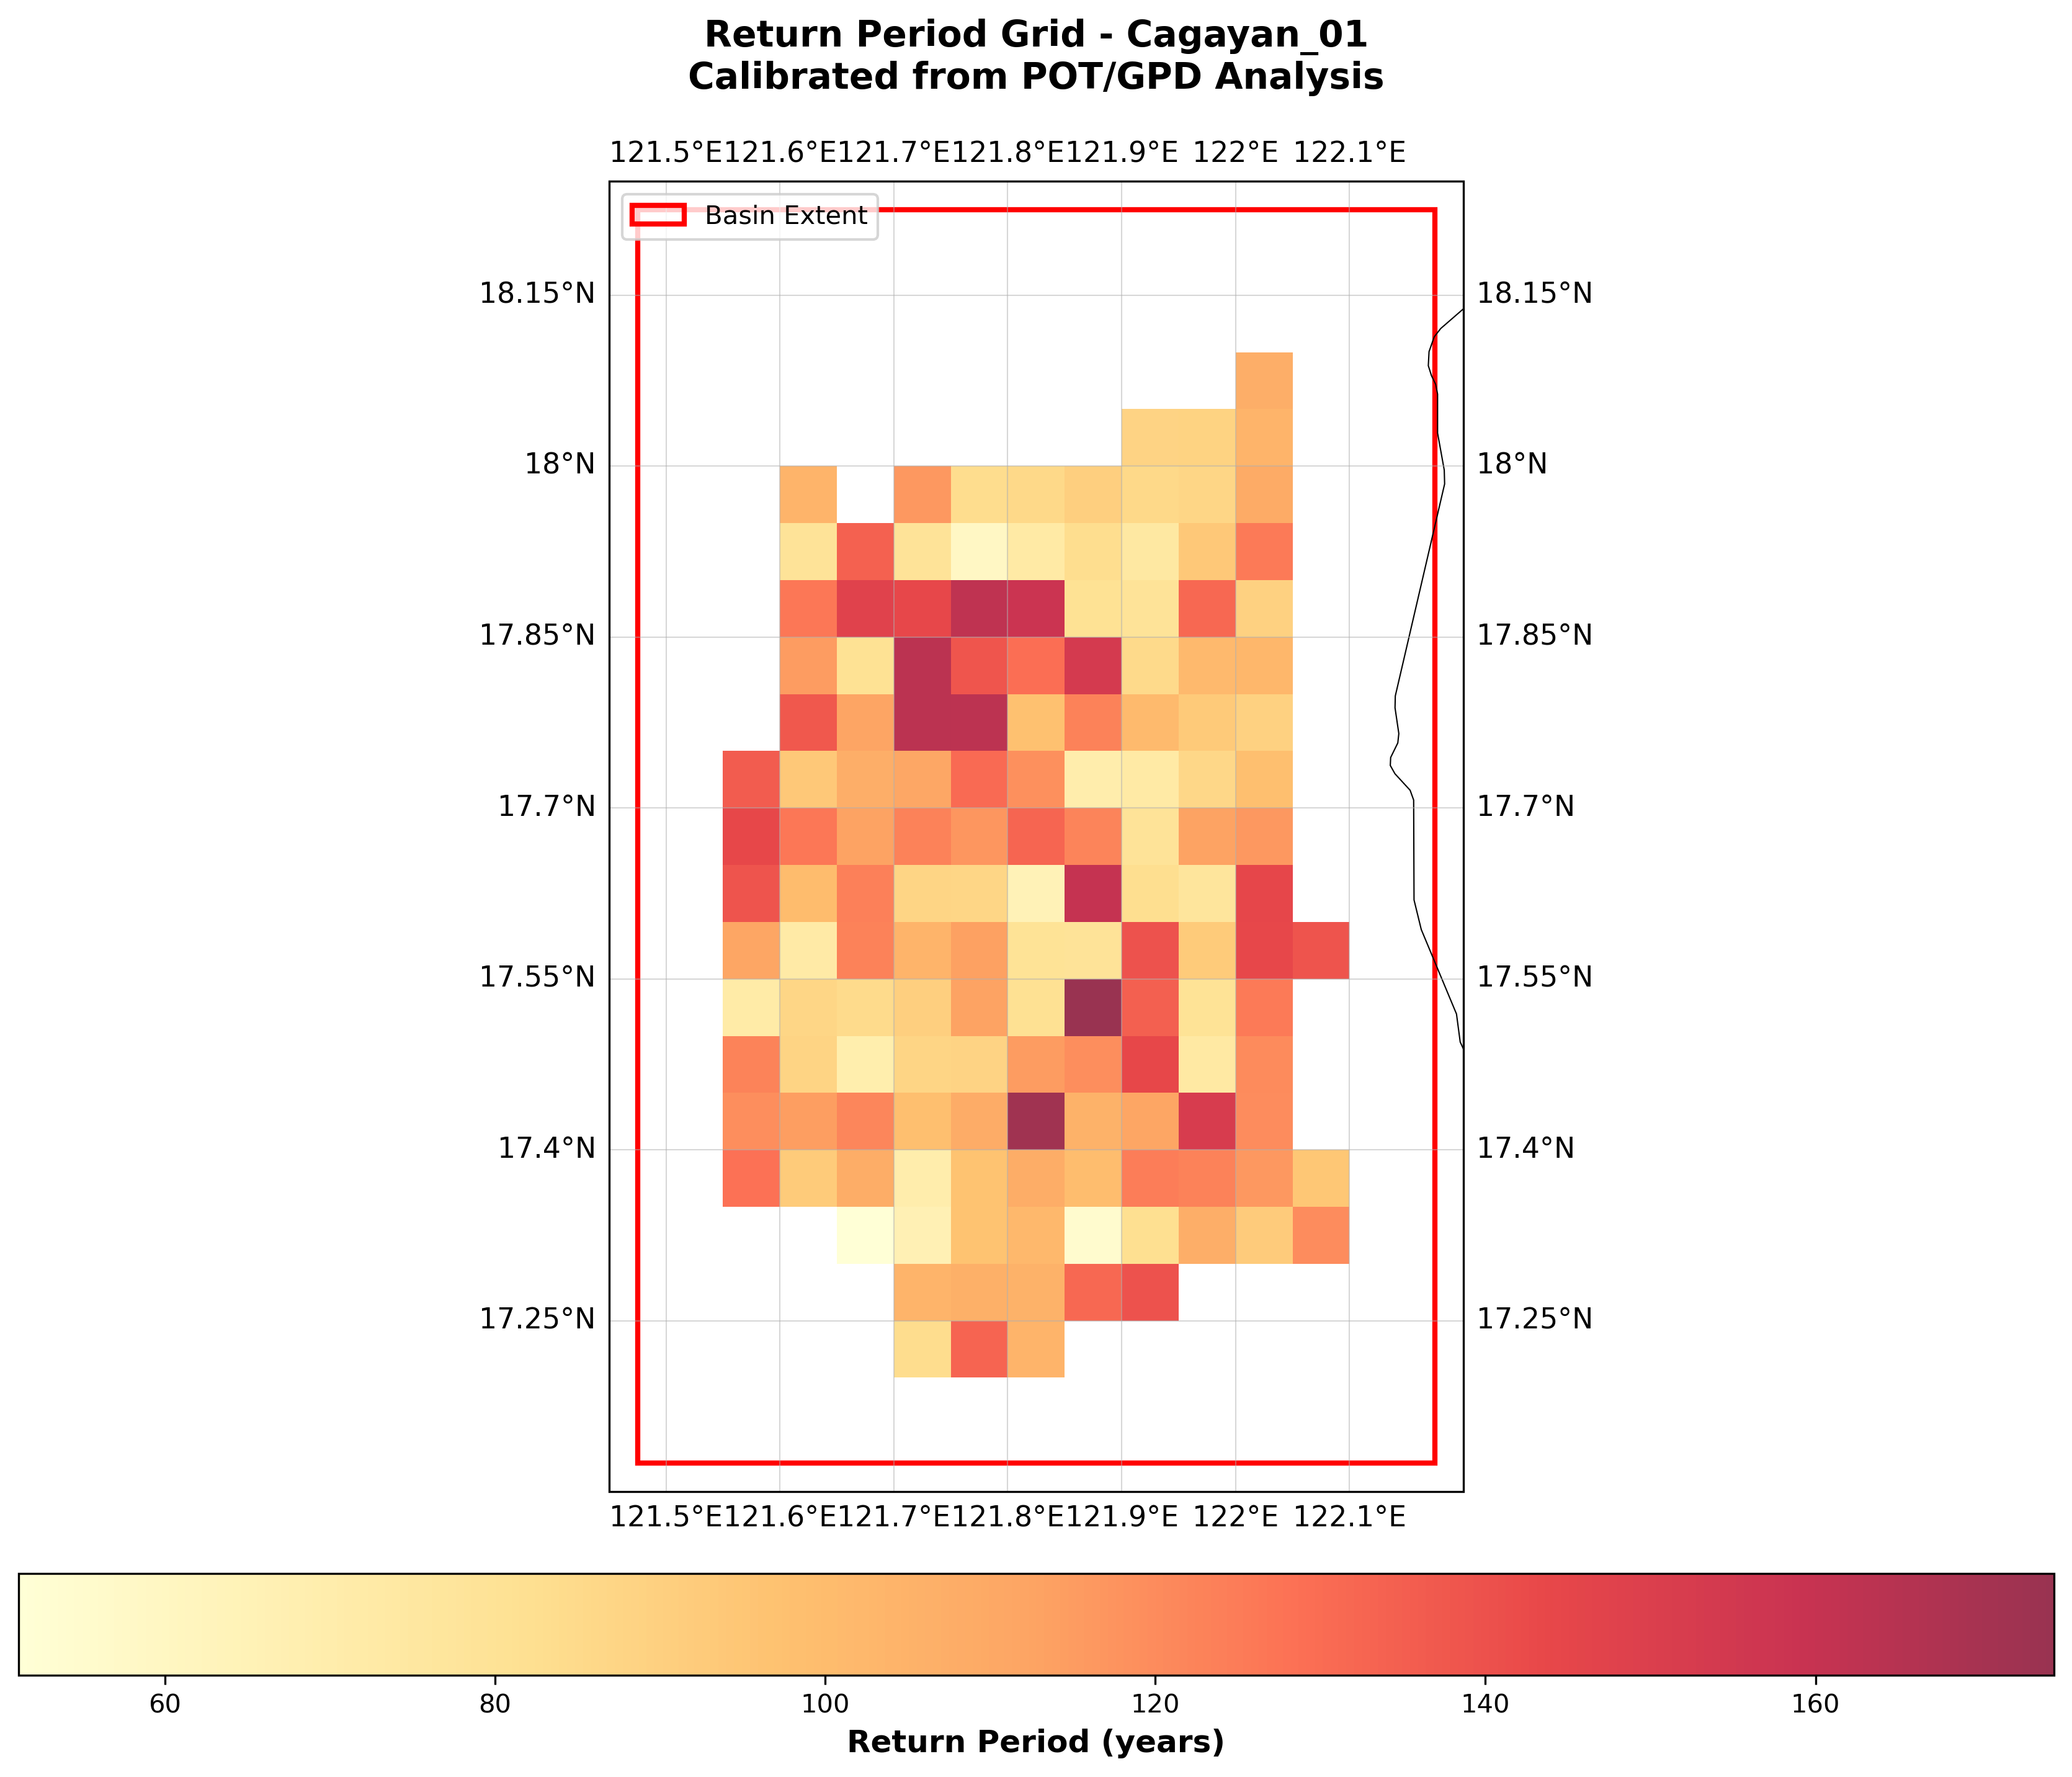

✓ Displayed: 01_return_period_map.png


Preview 2/5: 02_flood_depth_maps_by_rp.png



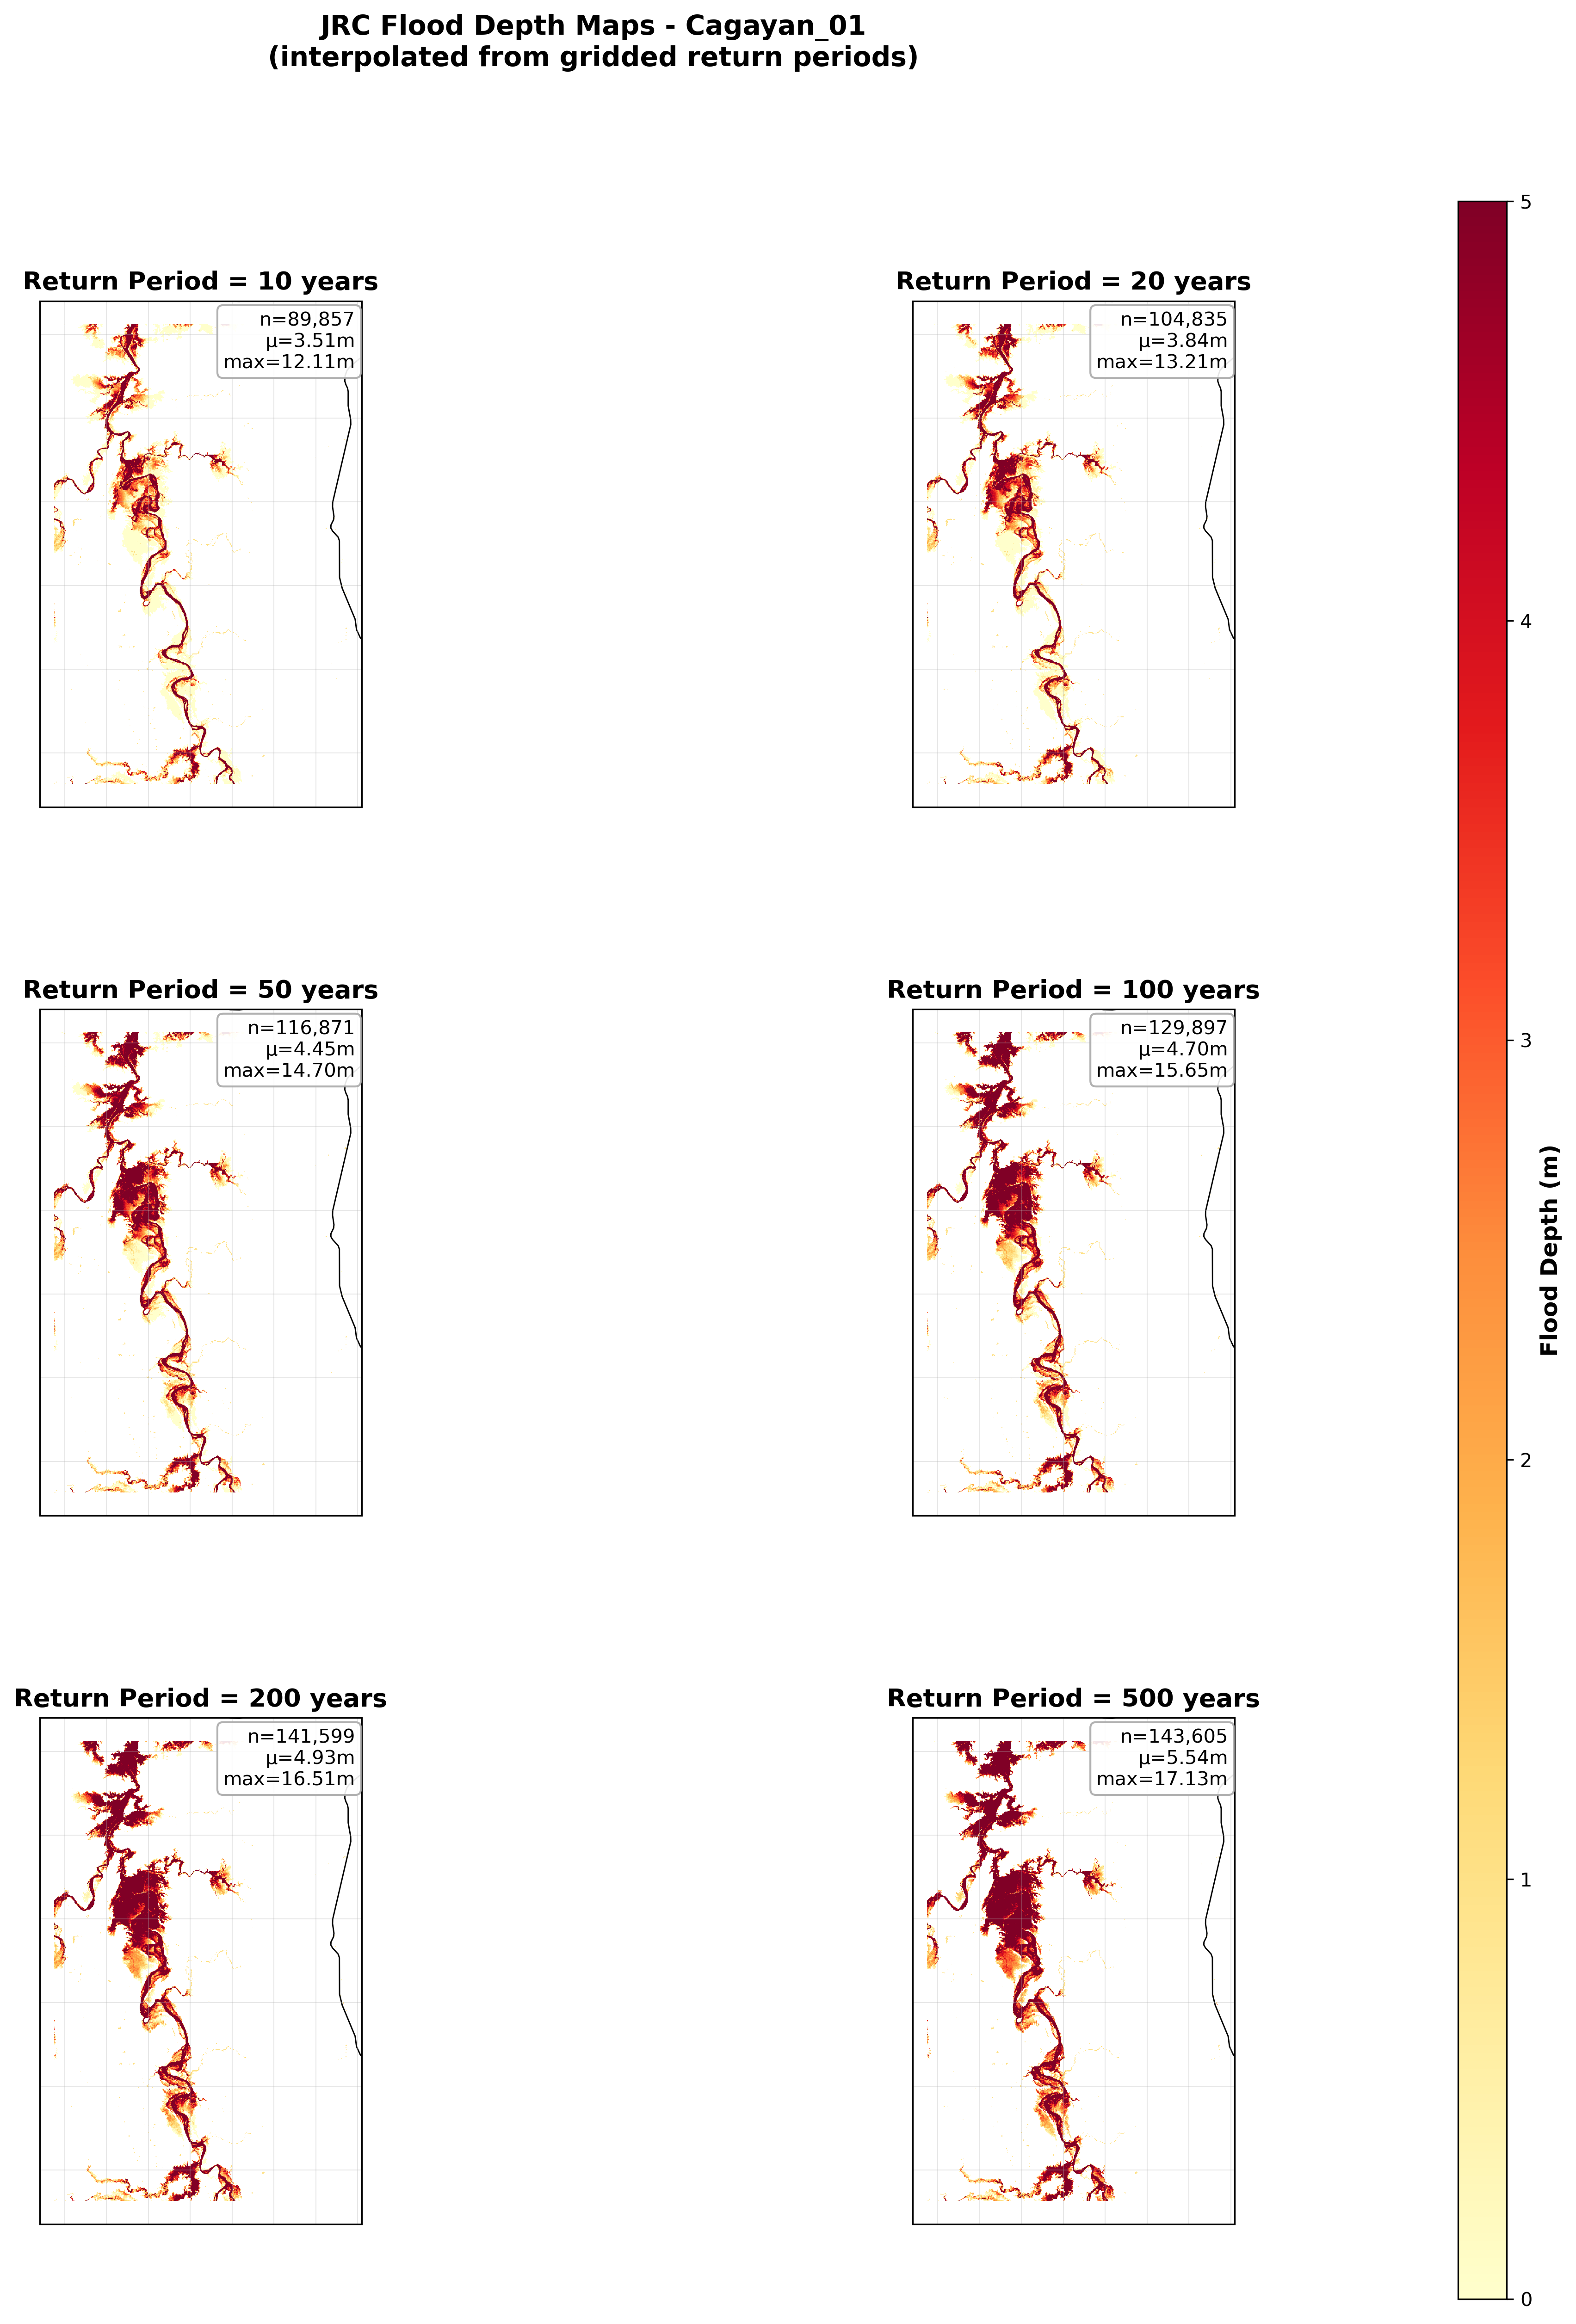

✓ Displayed: 02_flood_depth_maps_by_rp.png


Preview 3/5: 03_hazard_intensity_heatmap.png



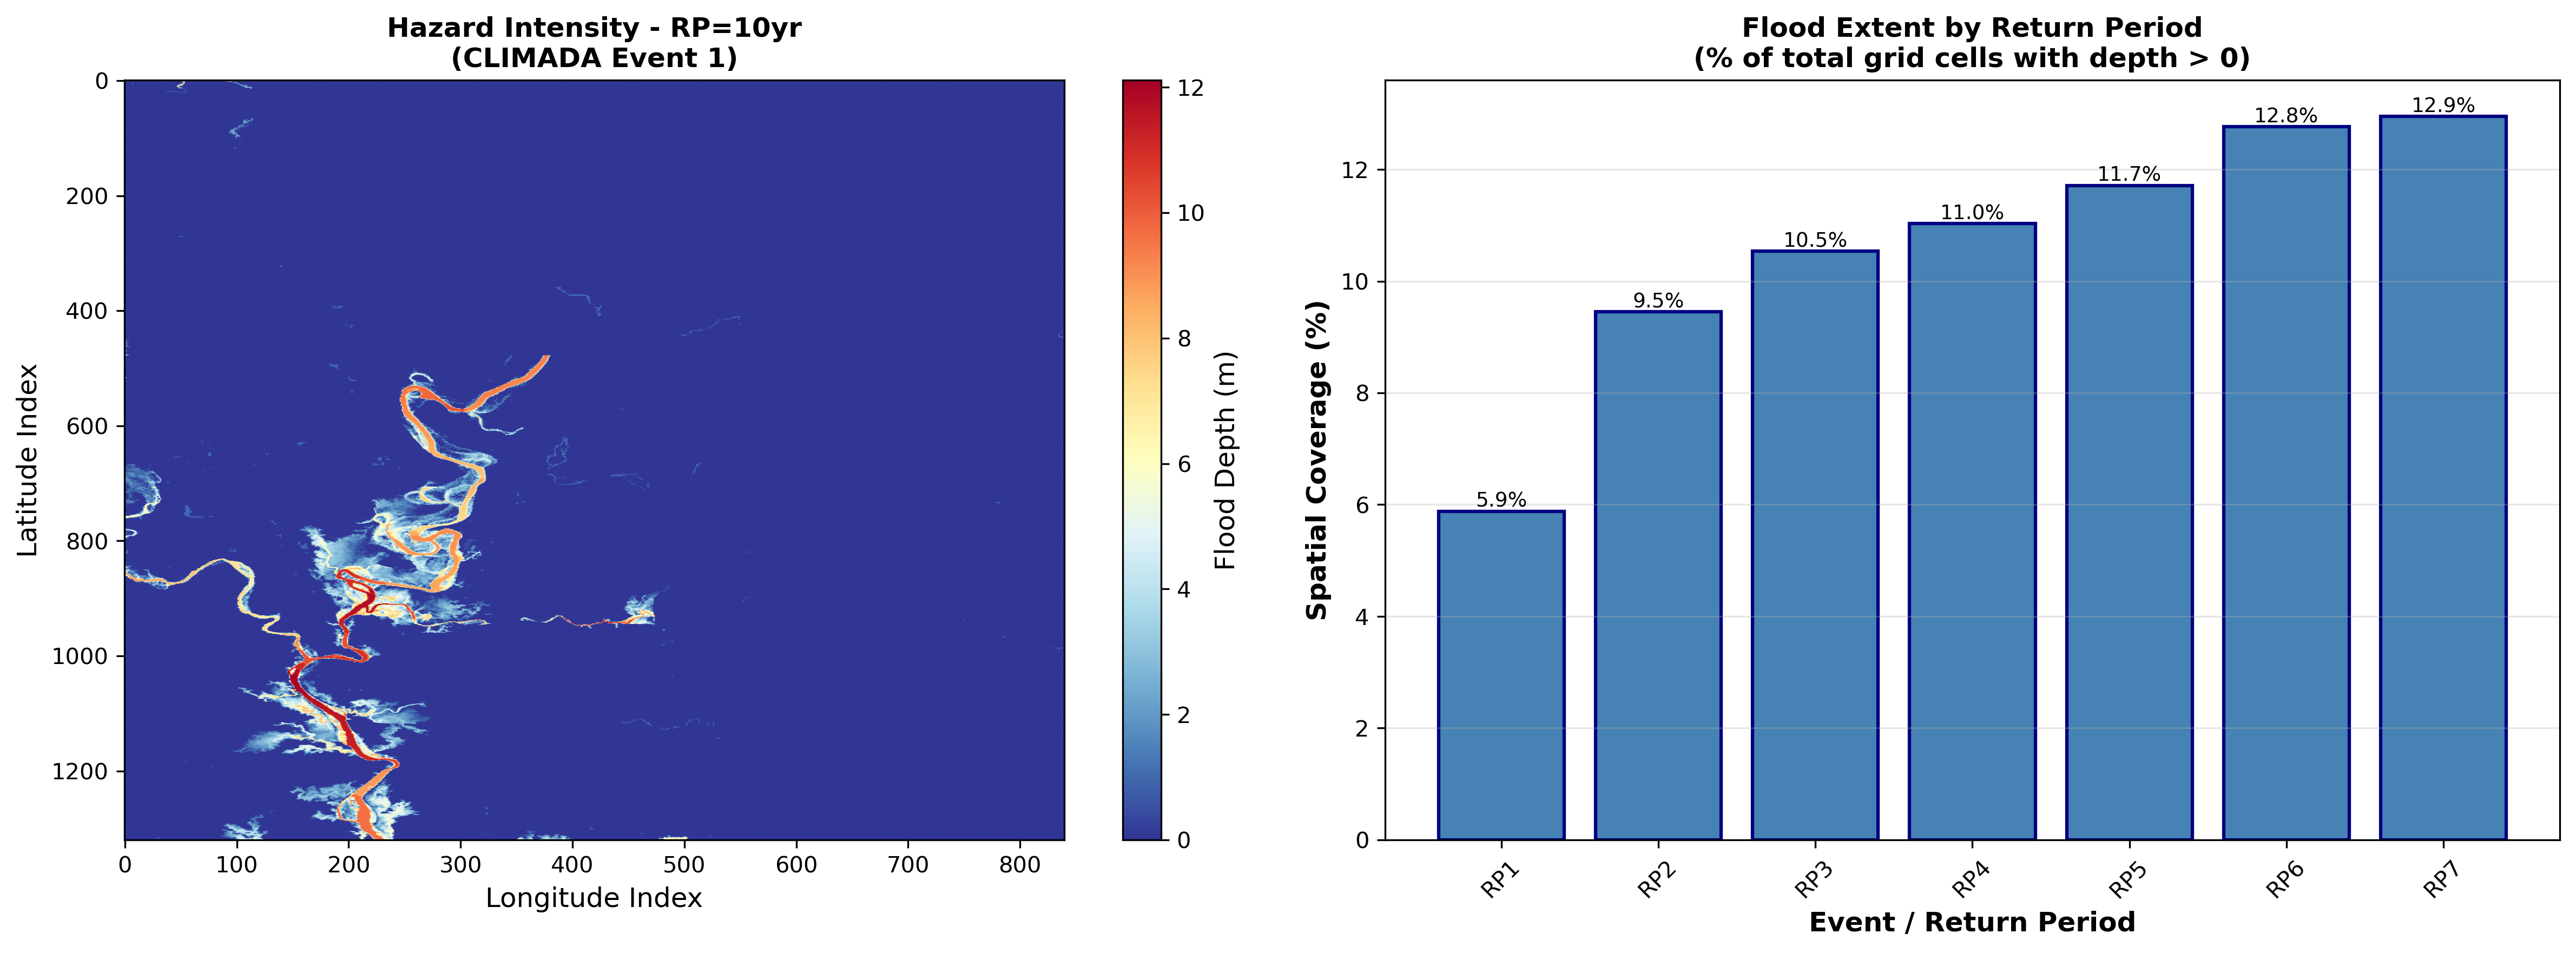

✓ Displayed: 03_hazard_intensity_heatmap.png


Preview 4/5: 04_exceedance_frequency_curves.png



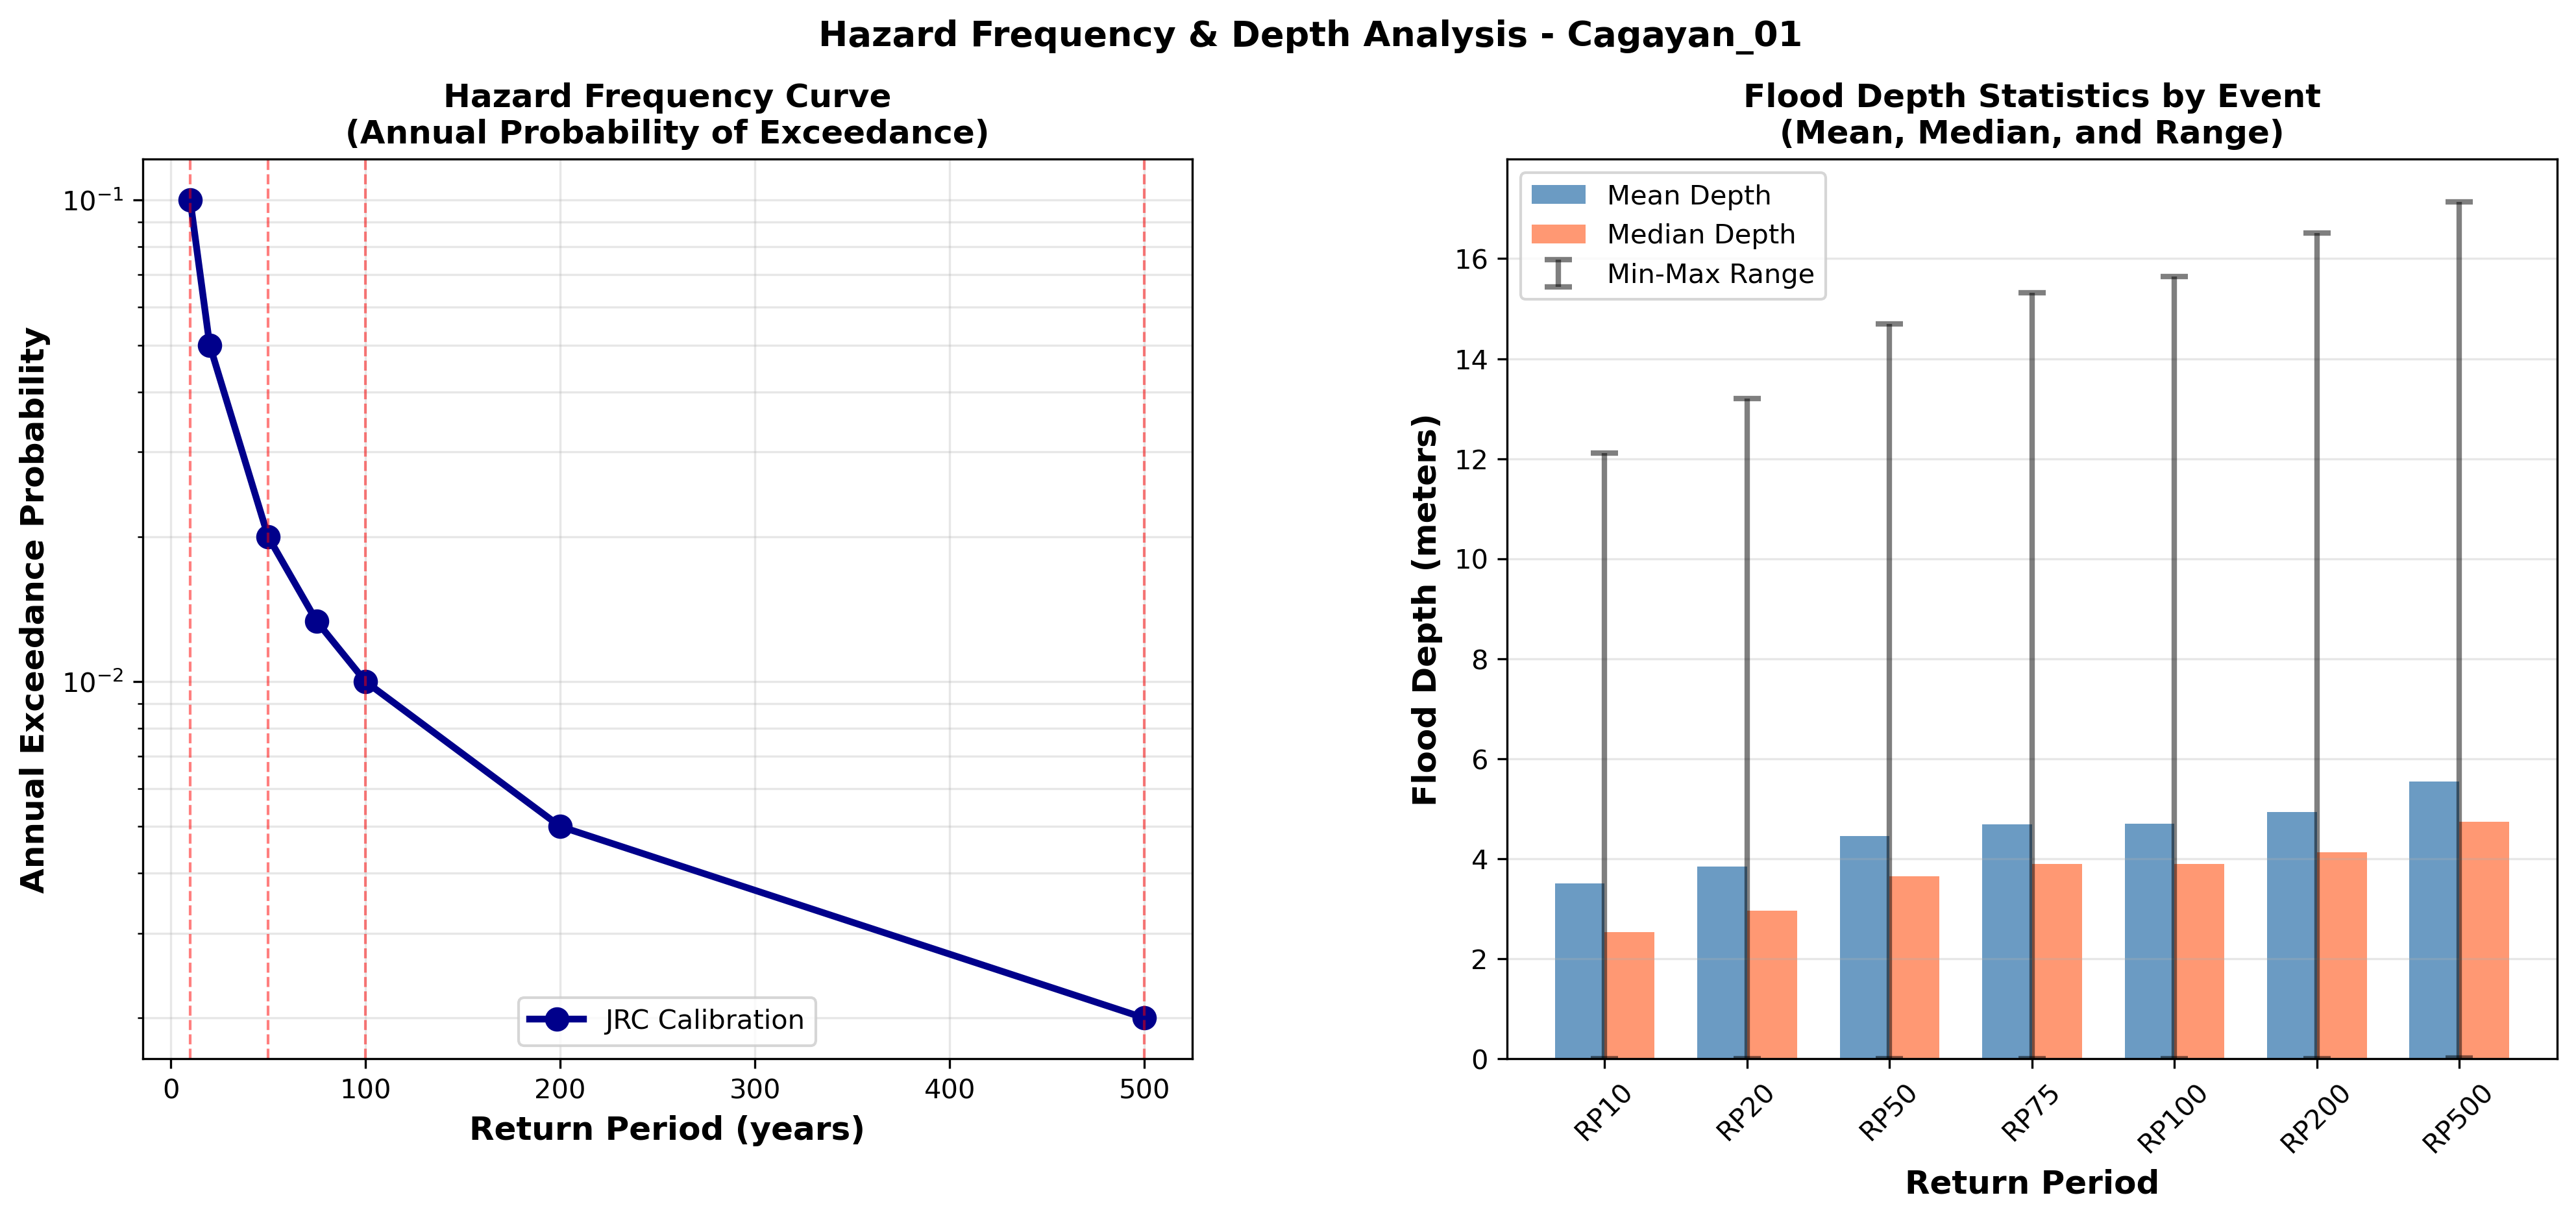

✓ Displayed: 04_exceedance_frequency_curves.png


Preview 5/5: 05_event_summary_dashboard.png



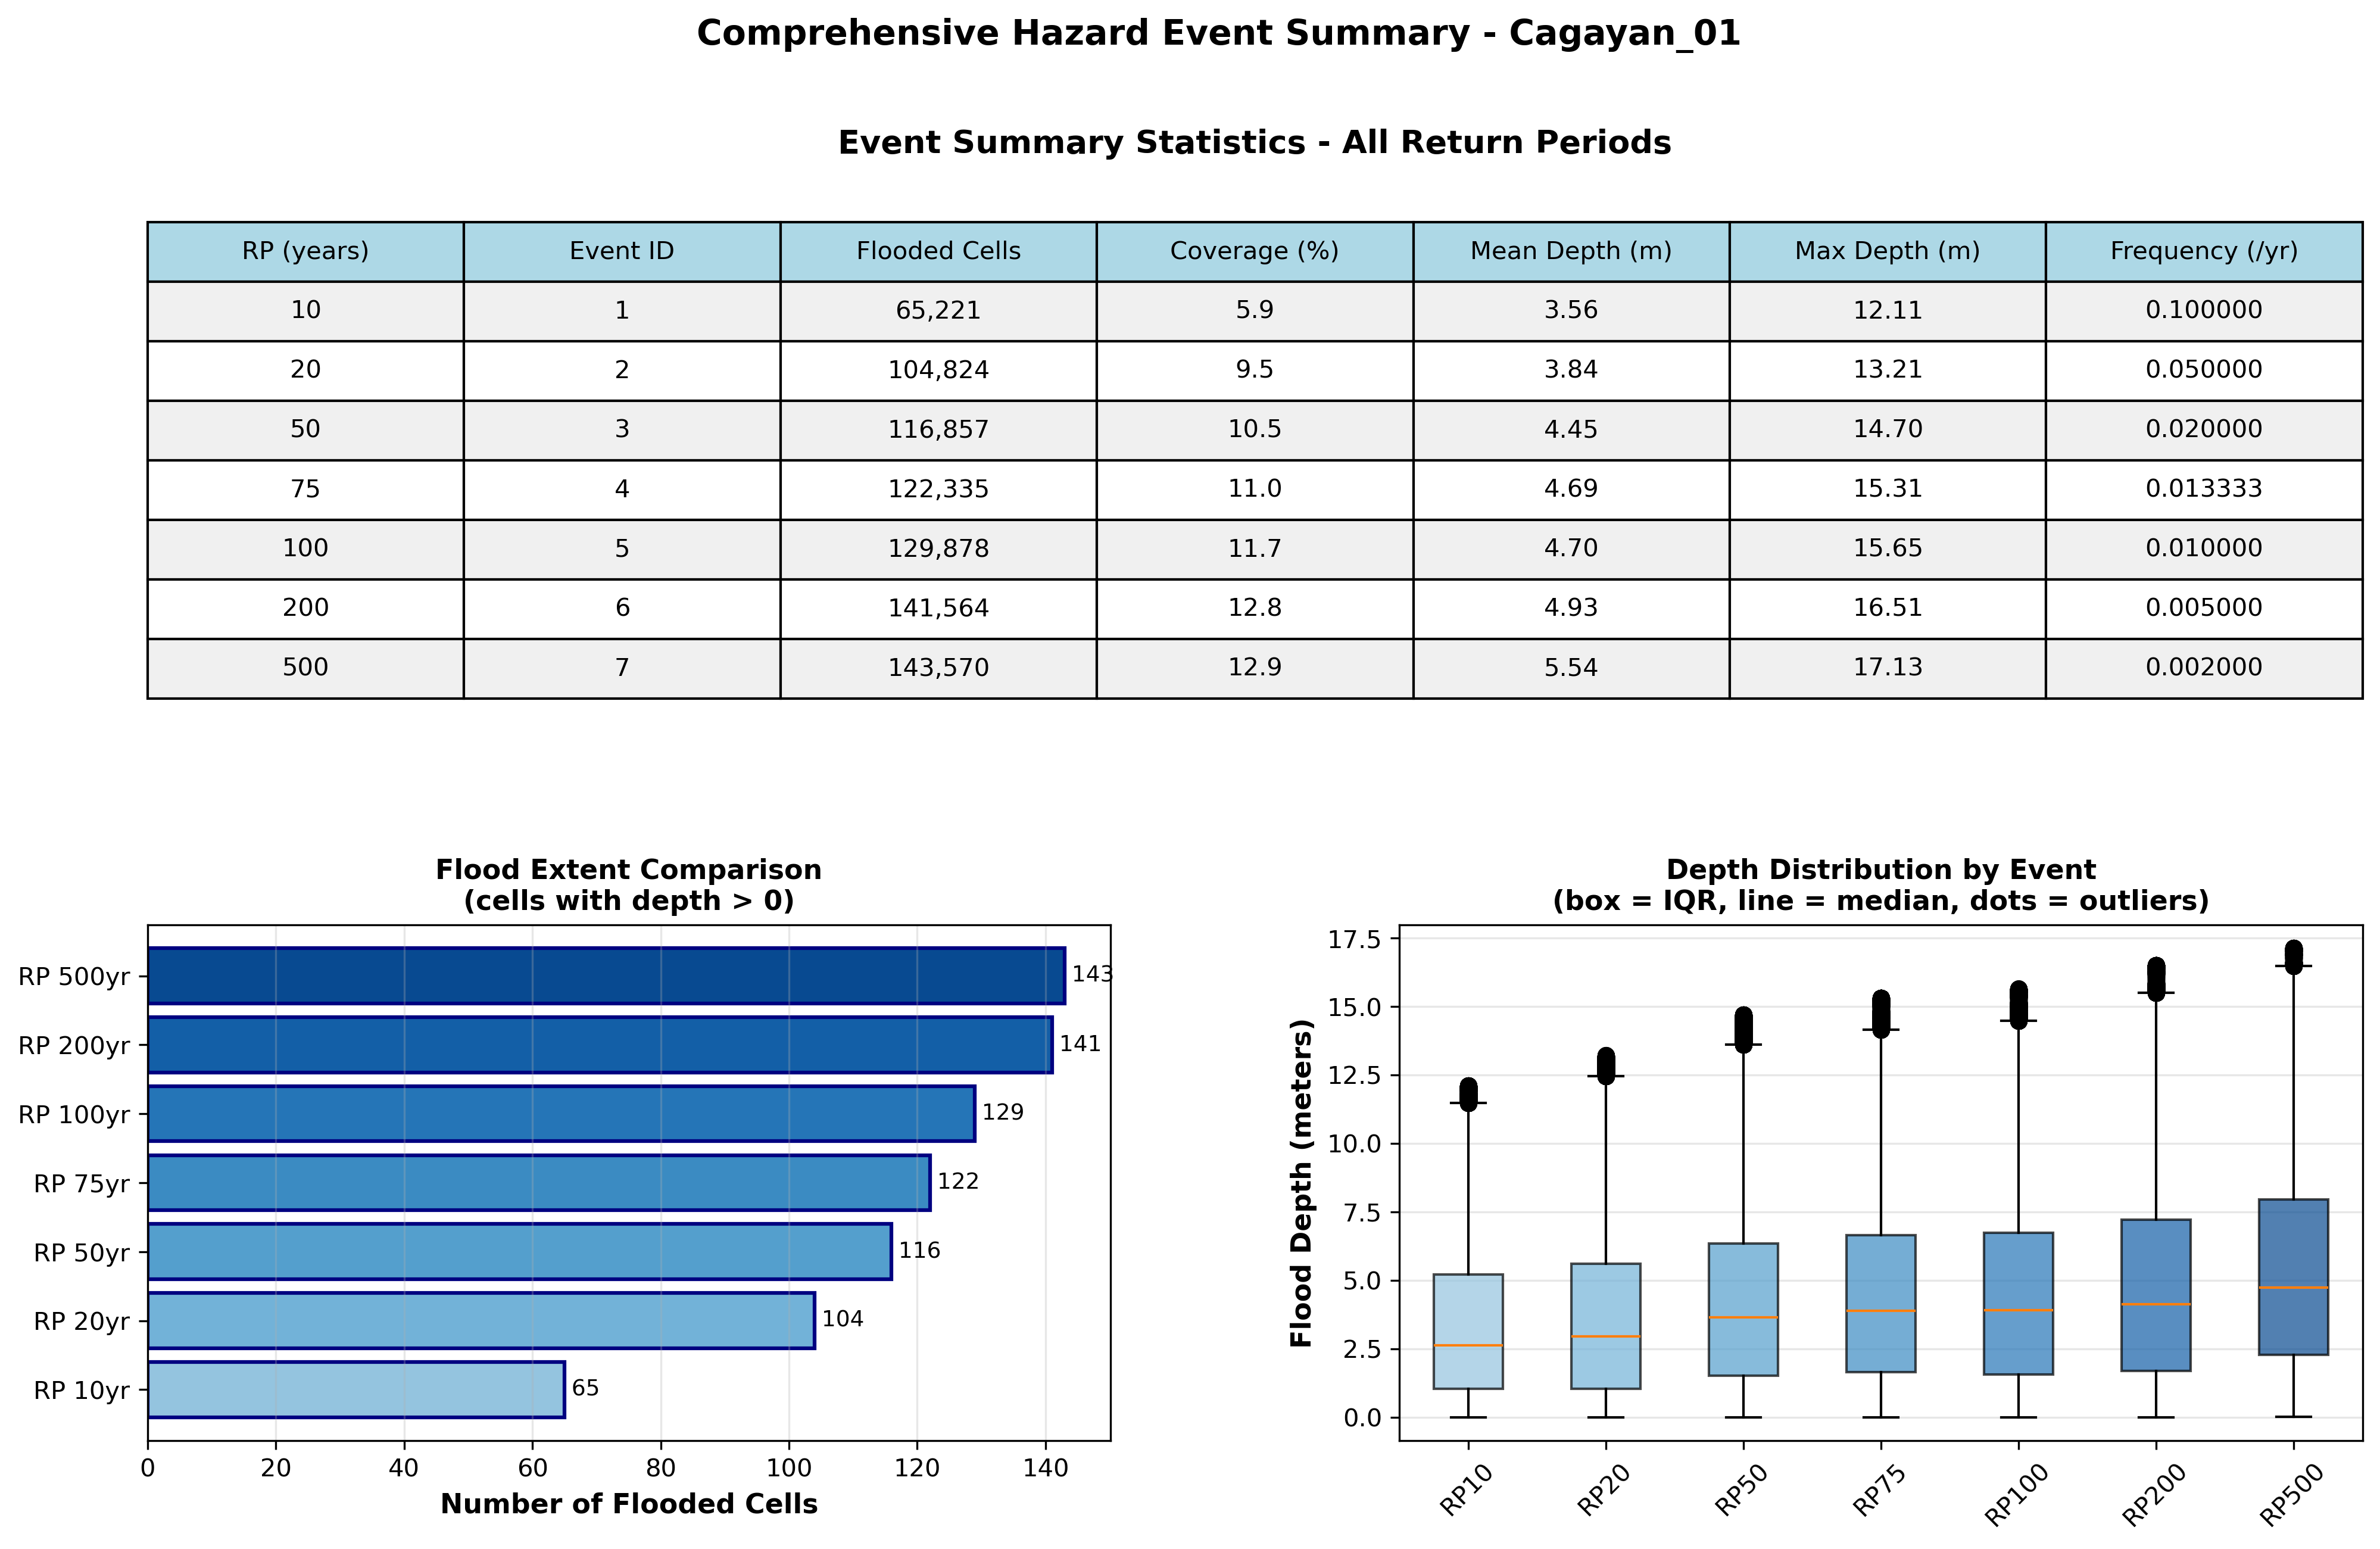

✓ Displayed: 05_event_summary_dashboard.png


FINAL VISUALIZATION SUMMARY

✓ Total visualizations generated: 6 files
✓ Total disk space: 3.5 MB
✓ All files saved in: c:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\climada_hazard\Cagayan_01\2026-01-19_calib-test\visualizations

💾 Files ready for presentation packages (PowerPoint, reports, email)
📊 High-resolution PNG (300 DPI) suitable for professional printing
🌐 Interactive HTML map available for stakeholder web distribution


In [ ]:
# === Section 8.9: Display Previews (Inline) ===
print("\n📺 Displaying Visualization Previews...\n")

from IPython.display import Image as IPImage, display, HTML

# Display PNG previews
png_files = sorted(VIZ_OUTPUT.glob("*.png"))

for i, png_path in enumerate(png_files, 1):
    print(f"\n{'='*70}")
    print(f"Preview {i}/{len(png_files)}: {png_path.name}")
    print(f"{'='*70}\n")
    try:
        display(IPImage(filename=str(png_path), width=800))
        print(f"✓ Displayed: {png_path.name}\n")
    except Exception as e:
        print(f"⚠️  Could not display {png_path.name}: {e}\n")

# Summary stats for all visualizations
print("\n" + "="*70)
print("FINAL VISUALIZATION SUMMARY")
print("="*70)

viz_files = list(VIZ_OUTPUT.glob("*"))
total_size = sum(f.stat().st_size for f in viz_files)
print(f"\n✓ Total visualizations generated: {len(viz_files)} files")
print(f"✓ Total disk space: {total_size / (1024**2):.1f} MB")
print(f"✓ All files saved in: {VIZ_OUTPUT}")
print(f"\n💾 Files ready for presentation packages (PowerPoint, reports, email)")
print(f"📊 High-resolution PNG (300 DPI) suitable for professional printing")
print(f"🌐 Interactive HTML map available for stakeholder web distribution")